# Модуль 1. Введение в классический ML

## 5/10   Введение в градиентный спуск


### Упрощенный пример поиска максимума через расчет значения производной для одномерной функции


Исходная функция:

$f(x)=x^{2}-6 * x+5$

Производная по $х$:

$\frac{\partial f}{\partial x}=f^{\prime}(x)=2 * x-6$

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 2.305125096759656e+33 в точке -4.801171832750475e+16


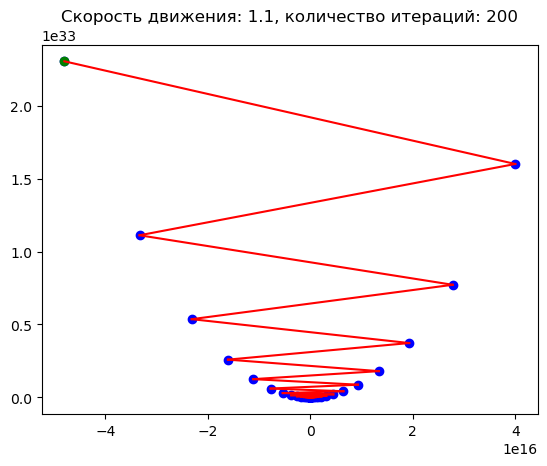

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x*x - 6*x + 5

def dfdx(x):
  return 2*x - 6

N = 200 #количество итераций
lr = 1.1 #скорость оптимизации

fig, ax = plt.subplots()
ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

x_plot = np.arange(-5, 11, 0.01)
y_plot = [f(x) for x in x_plot]
ax.plot(x_plot, y_plot)

xc = -4 #начальное значение
print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

ax.scatter(xc, f(xc), c='r')
for _ in range(N):
  x0 = xc #нужно только для графика

  xc = xc - lr*dfdx(xc) #сам по себе градиентный спуск

  ax.scatter(xc, f(xc), c='b') #нужно только для графика
  ax.plot([x0,xc],[f(x0), f(xc)], c='r') #нужно только для графика

ax.scatter(xc, f(xc), c='g')

print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # <--- Важно для отображения

# 1. Функции
def f(x): return x**2 - 6*x + 5
def dfdx(x): return 2*x - 6

# 2. Подготовка данных
x_cur = 0.2
lr = 1.1
steps = 25
history_x = [x_cur]
for _ in range(steps):
    x_cur = x_cur - lr * dfdx(x_cur)
    history_x.append(x_cur)

# 3. Настройка графика
fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.linspace(-300, 300, 2000)
ax.plot(x_axis, f(x_axis), color='lightgray', zorder=1)
ax.set_ylim(-500, 75000)

dot, = ax.plot([], [], 'ro', label='Спуск', zorder=3)
line, = ax.plot([], [], 'r--', alpha=0.4, zorder=2)
title = ax.set_title('')

# Скрываем создание лишнего статического графика
plt.close() 

# 4. Функция обновления
def update(i):
    curr_x_pts = history_x[:i+1]
    curr_y_pts = [f(x) for x in curr_x_pts]
    
    line.set_data(curr_x_pts, curr_y_pts)
    dot.set_data([history_x[i]], [f(history_x[i])])
    title.set_text(f'Шаг {i}: x = {history_x[i]:.2f}')
    return line, dot

# 5. Создание и отображение
ani = FuncAnimation(fig, update, frames=len(history_x), interval=300, blit=True)

# Самая важная строка для Jupyter:
HTML(ani.to_jshtml())


Начальное значение минимума: 45 в точке -4
Финальное значение минимума: 2.305125096759656e+33 в точке -4.801171832750475e+16


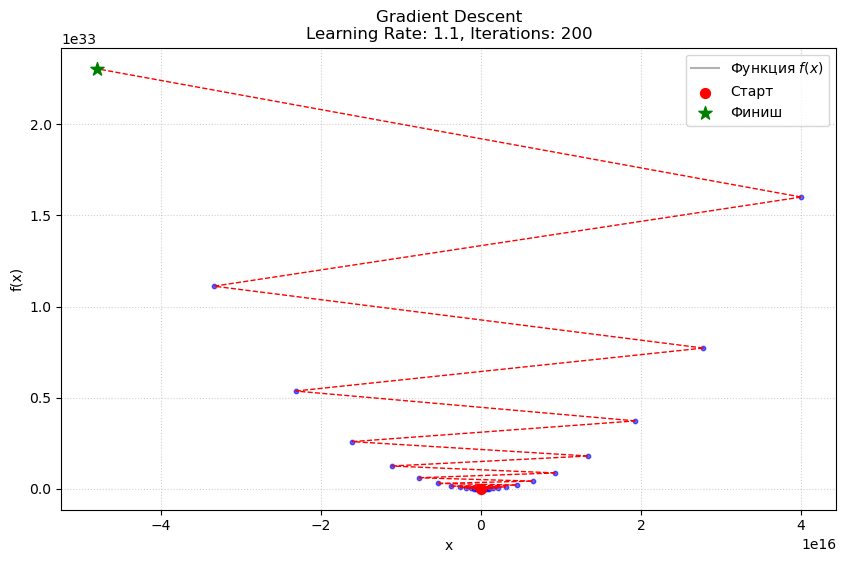

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем "полотно" (fig) и "оси" (ax) для рисования. 
# figsize=(10, 6) задает размер окна в дюймах.
fig, ax = plt.subplots(figsize=(10, 6))

# --- 1. ОТРИСОВКА ГРАФИКА ФУНКЦИИ ---
# Создаем массив чисел от -5 до 11 с шагом 0.01
x_plot = np.arange(-5, 11, 0.01)
# Вычисляем y для каждого x. 
y_plot = [f(x) for x in x_plot]
# Рисуем саму параболу. alpha=0.3 делает её полупрозрачной (фоновой), 
# чтобы она не отвлекала от шагов алгоритма.
ax.plot(x_plot, y_plot, label='Функция $f(x)$', color='black', alpha=0.3)

# --- 2. НАЧАЛЬНАЯ ТОЧКА ---
xc = -4  # Устанавливаем стартовую точку x
print(f'Начальное значение минимума: {f(xc)} в точке {xc}')
# Рисуем большую красную точку 'r' на старте. 
# zorder=5 гарантирует, что точка будет ПОВЕРХ линий.
ax.scatter(xc, f(xc), c='r', s=50, label='Старт', zorder=5)

# --- 3. ЦИКЛ ГРАДИЕНТНОГО СПУСКА ---
for i in range(N):
    x0 = xc  # Сохраняем старый x, чтобы нарисовать линию перехода
    # ГЛАВНАЯ ФОРМУЛА: делаем шаг против градиента
    xc = xc - lr * dfdx(xc)
    
    # Рисуем маленькую синюю точку 'b' в новом положении
    ax.scatter(xc, f(xc), c='b', s=10, alpha=0.6)
    # Рисуем пунктирную красную линию от старого x0 к новому xc
    ax.plot([x0, xc], [f(x0), f(xc)], c='r', linestyle='--', linewidth=1)

# --- 4. ФИНАЛЬНАЯ ТОЧКА ---
# Рисуем большую зеленую звезду 'g' в месте, где алгоритм остановился после N итераций
ax.scatter(xc, f(xc), c='g', s=100, marker='*', label='Финиш', zorder=5)

# --- ОФОРМЛЕНИЕ ---
ax.set_title(f'Gradient Descent\nLearning Rate: {lr}, Iterations: {N}')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True, linestyle=':', alpha=0.6) # Легкая сетка
ax.legend() # Вывод легенды (подписи "Старт", "Финиш" и т.д.)

print(f'Финальное значение минимума: {f(xc)} в точке {xc}')

plt.show()


### Создание функции для расчета

In [4]:
def gd(N, lr, min = -5, max = 11, f=f, dfdx=dfdx, xc=-4):
    """
    Реализация и визуализация процедуры градиентного спуска 
    для конкретной функции в упрощенном примере.

    Parameters
    ----------
    N: integer
        Число шагов градиентного спуска, которые необходимо выполнить.
      
    lr: float
        Скорость обучения
    
    min: float
        Минимальное значение, отображаемое на графике
      
    max: float
        Максимальное значение, отображаемое на графике
    
    f: function
        Целевая функция
    
    dfdx: function
        Градиент целевой функции

    Returns
    ----------
    """
    fig, ax = plt.subplots()
    ax.set_title(f'Скорость движения: {lr}, количество итераций: {N}')

    x_plot = np.arange(min, max, 0.01)
    y_plot = [f(x) for x in x_plot]
    ax.plot(x_plot, y_plot)
  
    print(f'Начальное значение минимумума: {f(xc)} в точке {xc}')

    ax.scatter(xc, f(xc), c='r')

    for _ in range(N):
      x0 = xc #нужно только для графика

      xc = xc - lr*dfdx(xc) #сам по себе градиентный спуск

      ax.scatter(xc, f(xc), c='b') #нужно только для графика
      ax.plot([x0,xc],[f(x0), f(xc)], c='r') #нужно только для графика

    ax.scatter(xc, f(xc), c='g')

    print(f'Финальное значение минимумума: {f(xc)} в точке {xc}')
    plt.show()

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: 45 в точке -4


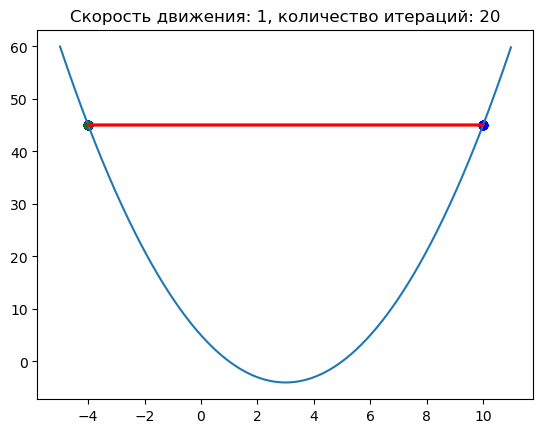

In [5]:
gd(20, 1, min=-5, max = 11)


Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.919295494677521


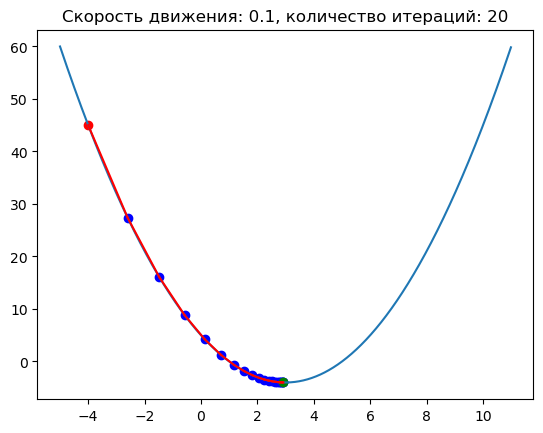

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


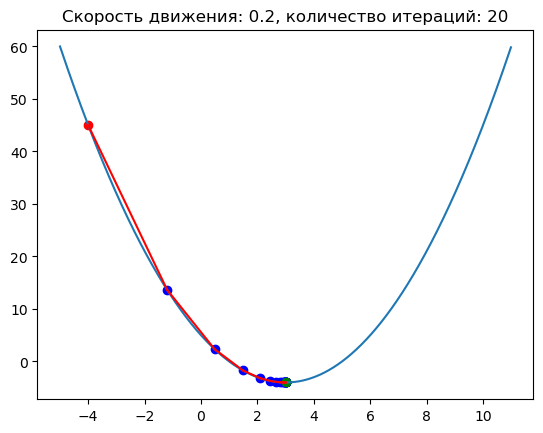

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


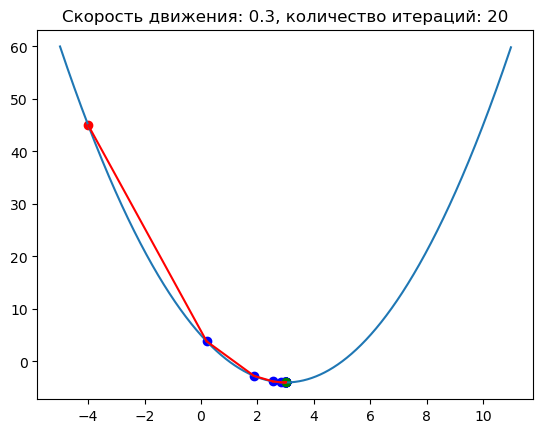

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 2.9999999999999267


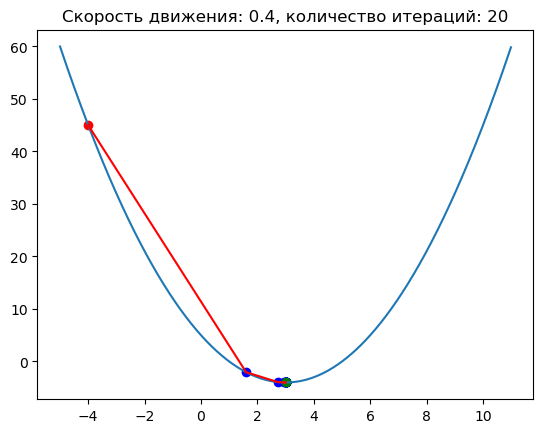

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 3.0


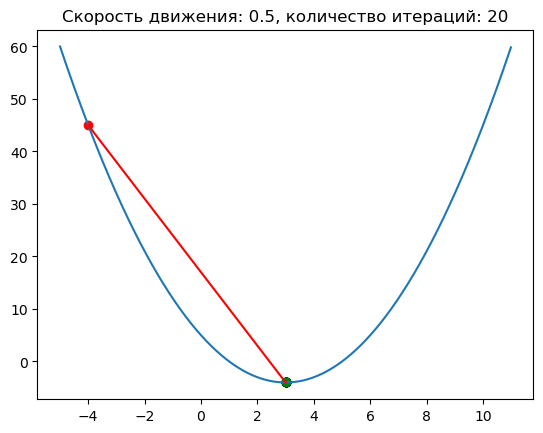

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -4.0 в точке 2.9999999999999267


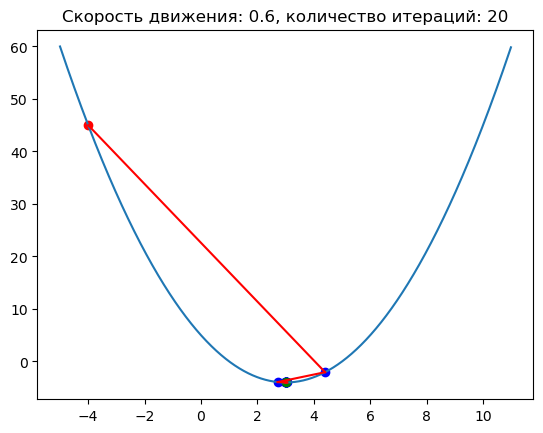

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999999999964 в точке 2.999999923034186


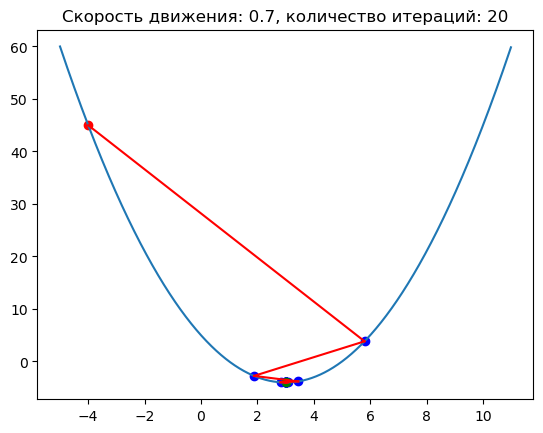

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9999999344992787 в точке 2.9997440689091954


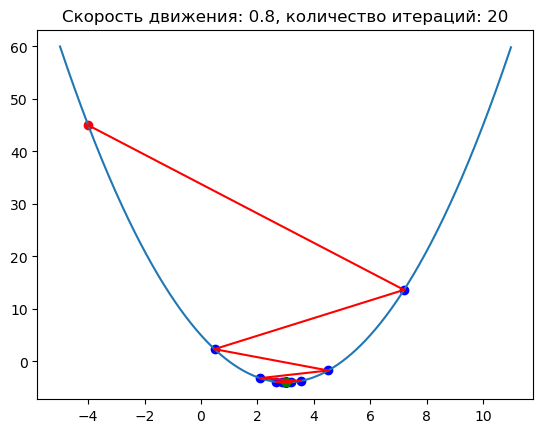

Начальное значение минимумума: 45 в точке -4
Финальное значение минимумума: -3.9934867828206553 в точке 2.9192954946775207


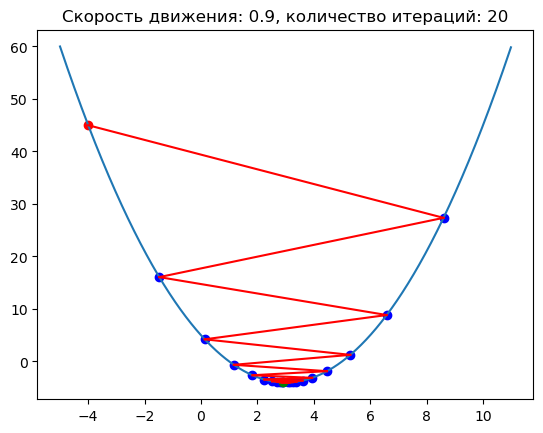

In [6]:
for i in range(1, 10):
  gd(N=20, lr=i/10)

## 6/10   Сложности оптимизации (локальные минимумы)


Рассмотрим более сложную функцию, чем во втором уроке:

$f_{2}(x)=x^{2}+15 * \sin (x)$

$f_{2}^{\prime}(x)=2 * x+15 * \cos (x)$

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f2(x):
  return x*x + 15*np.sin(x)

def df2dx(x):
  return 2*x + 15*np.cos(x)

Начальное значение минимумума: 91.83968333665945 в точке 10
Финальное значение минимумума: 4.529631081084053 в точке 4.129334334768743


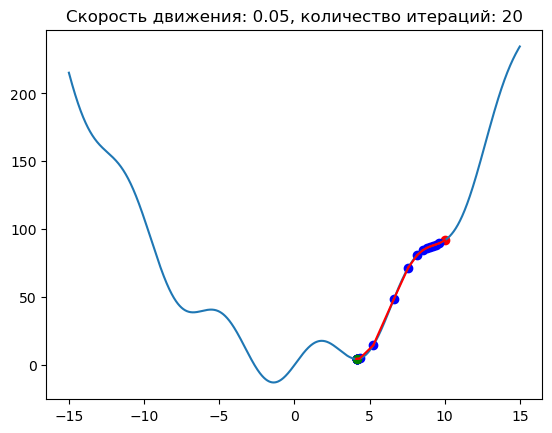

In [8]:
gd(20, 0.05, min=-15, max= 15, f=f2, dfdx=df2dx, xc=10)


Начальное значение минимумума: 39.38386411994708 в точке -5
Финальное значение минимумума: -12.823616841551932 в точке -1.3851303718795267


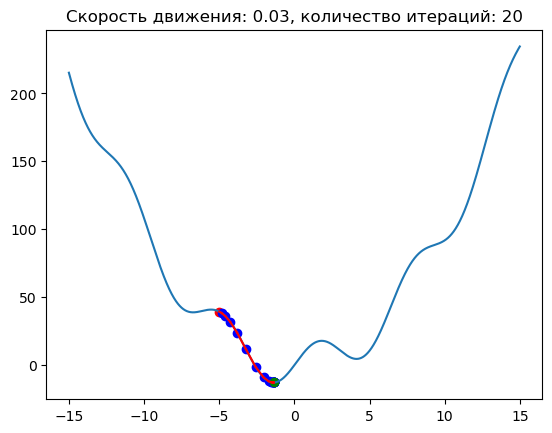

In [9]:
gd(20, 0.03, min=-15, max= 15, f=f2, dfdx=df2dx, xc=-5)


## 8/10   Градиентный спуск в машинном обучении (практическая часть)


In [10]:
from copy import deepcopy # лучший модуль для обеспечения реального копирования объектов
from tqdm import tqdm # библиотека для создания шкалы прогресса итерационного процесса

import seaborn
import numpy as np
import matplotlib.pyplot as plt

Сгенерируем данные $x$ — вектора признаков и $y$ — вектора значений целевой переменной:

In [11]:
std_error = 30 # коэффициент который нужен для генерации случайных данных в разбросе
sample_size = 10000 # размер выборки
theta0, theta1 = 1, 10 # параметры функции, описанной выше

x = np.random.randn(sample_size) # генерация случайной выборки
func_y = lambda x: theta0 + theta1 * x # лямбда-функция для расчета значений функции

y = func_y(x) + std_error * np.random.randn(sample_size) # расчет значений выборки с учетом случайного разброса

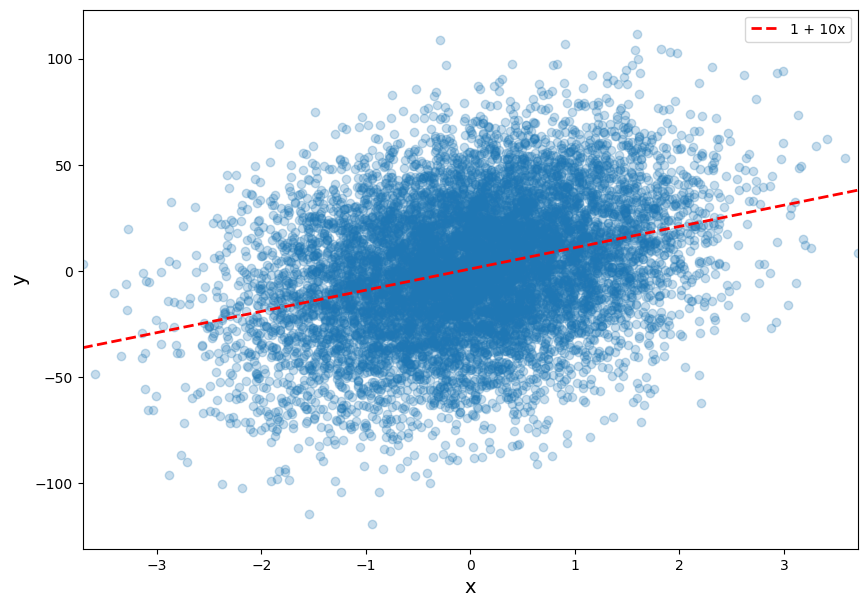

In [12]:
x_plot = np.linspace(x.min(), x.max(), 1000) 
y_plot = func_y(x_plot)

fig = plt.figure(figsize=(10, 7))
plt.scatter(x, y, alpha=0.25)
plt.plot(x_plot, y_plot, "r--", linewidth=2, label=f"{theta0} + {theta1}x")
plt.xlim(x.min(), x.max())
plt.xlabel("x", size=14)
plt.ylabel("y", size=14)
plt.legend(loc="best")

plt.show()

In [13]:
def calculate_predictions(theta0, theta1, X):
    """
    Вычисление значения функции для заданных коэффициентов и значений X.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, ]
        Вектор признаков.

    Returns
    -------
    y_pred: array-like, shape = [n_samples, ]
        Полученное значение функции.

    """
    return theta0 + theta1*X
    

def calculate_cost(theta0, theta1, X, y):
    """
    Вычисление значения функции потерь.

    Parameters
    ----------
    theta0: float
        Значение параметра theta0.

    theta1: float
        Значение параметра theta1.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    Returns
    -------
    cost: float
        Значение функции потерь.

    """
    theta0 = np.atleast_3d(np.asarray(theta0)) # перевод значений коэффициентов в удобный для работы программы вид
    theta1 = np.atleast_3d(np.asarray(theta1))

    y_pred = calculate_predictions(theta0, theta1, X)
    cost = np.average((y - y_pred)**2, axis=2)/2

    return cost


def gradient_descent_step(theta, X, y, learning_rate):
    """
    Один шаг градиентного спуска.

    Parameters
    ----------
    theta: array-like
        Массив значений параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    learning_rate: float
        Скорость обучения.

    Returns
    -------
    updated_theta: array-like
        Обновленный массив значений параметров theta.

    """
    n = len(y)
    y_pred = calculate_predictions(theta[0], theta[1], X)

    updated_theta = deepcopy(theta)
    updated_theta[0] -= learning_rate / n * np.sum((y_pred - y))
    updated_theta[1] -= learning_rate / n * np.sum((y_pred - y) * X)

    return updated_theta

    
def plot_gradient_descent(cost_history, theta_history, X, y):
    """
    Parameters
    ----------
    cost_history: list[float]
        Список со значениями функции потерь на каждой
        итерации обучения.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    """
    fig = plt.figure(figsize=(15, 15))
    plt.subplot(221)
    plt.scatter(range(len(cost_history)), cost_history)
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"J($\theta$)", size=14)

    plt.subplot(223)
    plt.scatter(x, y, alpha=0.15)
    x_plot = np.linspace(-3, 3, 500)
    for num, theta in enumerate(theta_history):
        y_plot = calculate_predictions(theta[0], theta[1], x_plot)
        if num == 0:
            plt.plot(x_plot, y_plot, color="green", label="Стартовая линия - baseline", linewidth=5)
        if num == len(theta_history) - 1:
            plt.plot(x_plot, y_plot, color="orange", label="Реузльтат работы", linewidth=5)
        else:
            plt.plot(x_plot, y_plot, "r--", alpha=.5)
    plt.xlim(x_plot.min(), x_plot.max())
    plt.xlabel("x", size=14)
    plt.ylabel("y", size=14)
    plt.plot(x_plot, func_y(x_plot), color = "black", label="Исходная линия", linewidth=3)
    plt.legend(loc="best")

    plt.subplot(222)
    x_plot = range(len(cost_history)+1)
    plt.scatter(x_plot, [theta[0] for theta in theta_history], label=r'$\theta_0$')
    plt.scatter(x_plot, [theta[1] for theta in theta_history], label=r'$\theta_1$')
    plt.xlabel("число итераций", size=14)
    plt.ylabel(r"$\theta$", size=14)
    plt.legend(loc="best")
    plt.subplot(224)
    plot_cost_function(X, y, theta_history)


def plot_cost_function(X, y, theta_history):
    """
    Визуализация процесса градиетного спуска и
    построение линий уровня.

    Parameters
    ----------
    X: array-like, shape = [n_samples, n_features]
        Вектор признаков.

    y: array-like, shape = [n_samples, ]
        Вектор целевой переменной.

    theta_history: list[np.array]
        Список двумерных массивов со значением параметров theta.

    """
    theta0 = [theta[0] for theta in theta_history]
    theta1 = [theta[1] for theta in theta_history]

    #theta0_grid = np.linspace(-5*min(theta0), max(theta0), 200)
    #theta1_grid = np.linspace(-5*min(theta1), max(theta1), 200)
    theta0_grid = np.linspace(-25, 25, 200)
    theta1_grid = np.linspace(-25, 25, 200)
    cost_grid = calculate_cost(
        theta0_grid[np.newaxis,:,np.newaxis],
        theta1_grid[:,np.newaxis,np.newaxis],
        X, y
    )
    X, Y = np.meshgrid(theta0_grid, theta1_grid)

    theta0, theta1 = theta_history[-1]
    plt.scatter([theta0]*2, [theta1]*2, s=[50, 0], color=['k','w'])
    contours = plt.contour(X, Y, cost_grid, 30)
    plt.clabel(contours)

    for it in range(1, len(theta_history)):
        plt.annotate(
            '', xy=theta_history[it], xytext=theta_history[it-1],
            arrowprops={'arrowstyle': '->', 'color': 'r', 'lw': 2},
            va='center', ha='center'
        )

    plt.scatter(*zip(*theta_history), color="black", s=40, lw=0)
    plt.xlim(theta0_grid.min(), theta0_grid.max())
    plt.ylim(theta1_grid.min(), theta1_grid.max())
    plt.xlabel(r'$\theta_0$', size=15)
    plt.ylabel(r'$\theta_1$', size=15)
    plt.title('Функция потерь', size=15)

In [14]:
n_iterations, learning_rate = 100, 0.5
theta_history, cost_history = [100*np.random.rand(2)], []

for it in tqdm(range(n_iterations)):
    last_theta = theta_history[-1]
    current_theta = gradient_descent_step(
        theta=last_theta, X=x, y=y, learning_rate=learning_rate
    )
    theta_history.append(current_theta)
    cost_history.append(calculate_cost(current_theta[0], current_theta[1], X=x, y=y))

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 12299.29it/s]


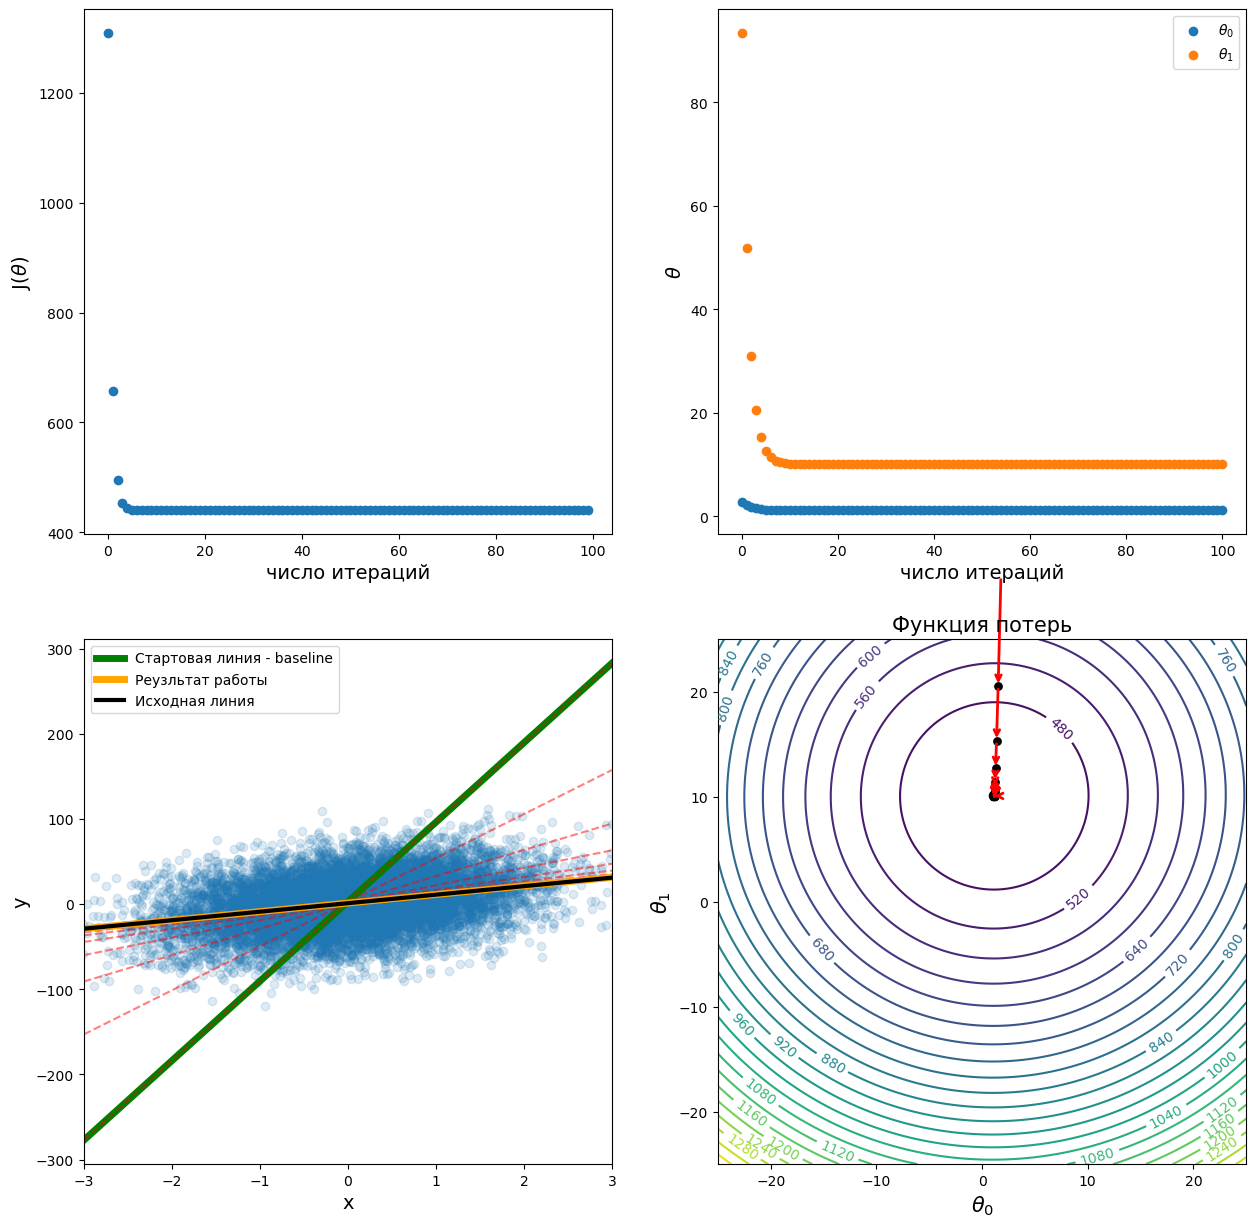

In [15]:
plot_gradient_descent(
    cost_history=cost_history,
    theta_history=theta_history,
    X=x, y=y
)

# Модуль 2. Регрессионные задачи


## 2/11   Задача регрессии

Задача расчёта оптимальных коэффициентов математически может быть записана следующим образом.

$Q(w, x)=\frac{1}{m} \sum_{i=1}^{m}\left(\left\langle w, x_{i}\right\rangle-y_{i}\right)^{2} \rightarrow \min _{w}$

$X=\left(\begin{array}{ccc}x_{11} & \ldots & x_{1 n} \\ \ldots & \ldots & \ldots \\ x_{m 1} & \ldots & x_{m n}\end{array}\right)$ и $\quad y=\left(\begin{array}{c}y_{1} \\ \ldots \\ y_{m}\end{array}\right)$

$Q(w, X)=\frac{1}{m}\|X w-y\|^{2} \rightarrow \min _{w}$

Взяв производную от матрицы и приравняв её к нулю (точка экстремума квадратичной функции), можно получить значения коэффициентов:

$w=\left(X^{T} X\right)^{-1} X^{T} y$

Подробности:
https://habr.com/ru/company/ods/blog/323890/#metod-naimenshih-kvadratov

Теперь напишем код на Python, который аналитически решает задачу выше методами линейной алгебры с использованием библиотеки NumPy:



In [1]:
import numpy as np

def linear_regression_analytical(X, y):
    # Добавляем столбец единичных значений для смещения (bias)
    X_b = np.c_[np.ones((X.shape[0], 1)), X]  
    
    # Вычисление коэффициентов по аналитической формуле
    # w = (X^T X)^-1 X^T y
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    
    return theta

# Пример данных
X = np.array([[1, 2], [2, 5], [3, 7], [4, 10]])  # Матрица признаков
y = np.array([5, 8, 10, 15])  # Целевая переменная

# Нахождение коэффициентов (включая смещение)
theta = linear_regression_analytical(X, y)

print("Коэффициенты модели (включая смещение):")
print(theta)

Коэффициенты модели (включая смещение):
[ 2.5 -2.   2. ]


## 3/11   Задача регрессии (self implementation)


In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Создадим класс линейной регрессии, который будет содержать ключевые методы для решения задачи — конструктор класса, метод обучения алгоритма, метод пересчета весов и метод, делающий предсказания на основе найденного уравнения:

In [64]:
class LinearRegressionScratch() :

    def __init__(self, learning_rate, iterations) :
        self.lr = learning_rate
        self.iter = iterations
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, Y) :
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.iter) :
            loss = self.update_weights(X, Y)
            self.loss_history.append(loss)

    def update_weights(self, X, Y) :
        n = X.shape[0]
        preds = X @ self.w + self.b
        e = preds - Y

        # градиент
        dw = 1/n * X.T @ e
        db = 1/n * np.sum(e)

        # обновление весов
        self.w -= self.lr * dw
        self.b -= self.lr * db

        # MSE
        return np.mean(e**2)

    def predict( self, X ) :
        
        return X @ self.w + self.b

In [66]:
import numpy as np

X = np.array([[1], [2], [3], [4]])
y = np.array([3, 5, 7, 9])  # y = 2x + 1

model = LinearRegressionScratch(0.1, 3000)
model.fit(X, y)

print(f'{model.w[0]:.3f} {model.b:.3f}')

2.000 1.000


In [67]:
import numpy as np

X = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 6, 8])  # y = 2x

model = LinearRegressionScratch(0.1, 3000)
model.fit(X, y)

print(f'{model.w[0]:.3f} {model.b:.3f}')

2.000 0.000


In [69]:
import numpy as np

X = np.array([
    [1, 1],
    [2, 1],
    [3, 1],
    [4, 1]
])
Y = np.array([3, 5, 7, 9])  # y = 2*x1 + 1*x2

model = LinearRegressionScratch(0.1, 2000)
model.fit(X, Y)

print(' '.join(f'{w:.3f}' for w in model.w), f'{model.b:.3f}')

2.000 0.500 0.500


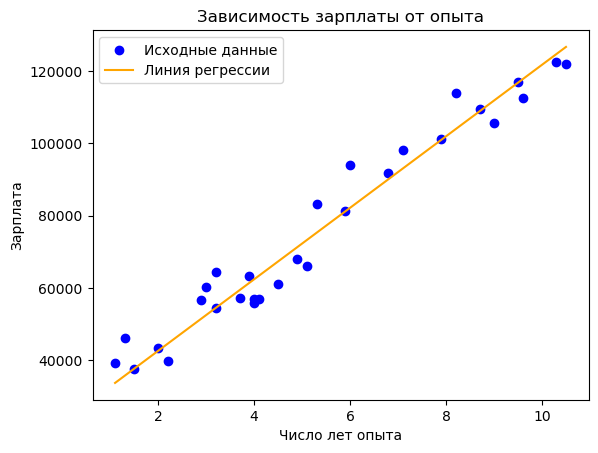

In [9]:
df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

model = LinearRegressionScratch(iterations = 1000, learning_rate = 0.01)
model.fit(X, Y)

Y_pred = model.predict(X)

plt.scatter(X, Y, color = 'blue', label='Исходные данные')
plt.plot(X, Y_pred, color = 'orange', label='Линия регрессии')
plt.title('Зависимость зарплаты от опыта')
plt.xlabel('Число лет опыта')
plt.ylabel('Зарплата')
plt.legend()

plt.show()

## 4/11   Задача регрессии (sklearn)

In [10]:
import numpy as np 
from sklearn.linear_model import LinearRegression

x = np.array([5, 15, 25, 35, 45, 55]).reshape((-1, 1))
y = np.array([5, 20, 14, 32, 22, 38])

In [11]:
x

array([[ 5],
       [15],
       [25],
       [35],
       [45],
       [55]])

In [12]:
y

array([ 5, 20, 14, 32, 22, 38])

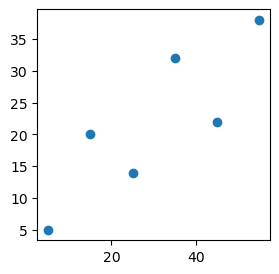

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(x, y)
plt.show()

In [14]:
model = LinearRegression()

In [15]:
model.fit(x, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
w0 = model.intercept_
w1 = model.coef_

In [17]:
w0

np.float64(5.633333333333329)

In [18]:
w1

array([0.54])

In [19]:
y_pred = model.predict(x)


In [20]:
y_pred

array([ 8.33333333, 13.73333333, 19.13333333, 24.53333333, 29.93333333,
       35.33333333])

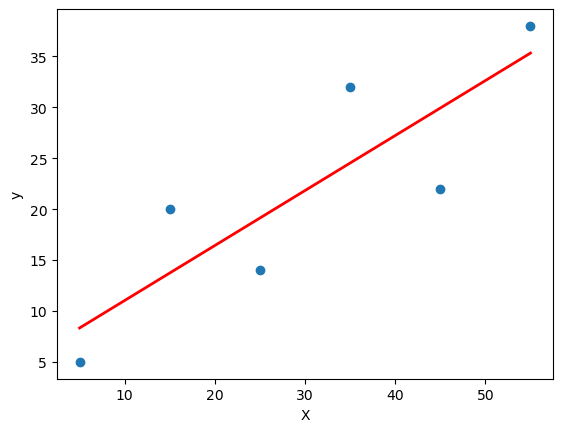

In [21]:
plt.scatter(x, y)
plt.plot(x, y_pred, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

Вы также можете проверить полученные результаты аналитическими вычислениями:

In [22]:
X_b = np.c_[np.ones((x.shape[0], 1)), x]
np.linalg.inv(X_b.T@X_b)@X_b.T@y

array([5.63333333, 0.54      ])

## 5/11   Оценка моделей регрессии


**Среднеквадратичная ошибка (Mean Squared Error, MSE)**

$M S E=\frac{1}{m} \sum_{i=0}^{m}\left(y_{i}-\hat{y}_{i}\right)^{2}$

$M A E=\frac{1}{m} \sum_{i=0}^{m}\left|y_{i}-\hat{y}_{i}\right|$

**Коэффициент детерминации**

Коэффициент детерминации, или $R^{2}$, измеряет долю дисперсии целевой переменной, которую модель объясняет. Этот коэффициент варьируется от бесконечности до $1$.

Значение $R^{2}$, близкое к $1$, говорит о том, что модель хорошо объясняет данные, а значение, близкое к $0$, указывает на то, что модель плохо объясняет данные.

$R^{2}=1-\frac{\sum_{i=1}^{m}\left(y_{i}-\hat{y}_{i}\right)^{2}}{\sum_{i=0}^{m}\left(y_{i}-\bar{y}_{i}\right)^{2}}$

Коэффициент $R^{2}$ говорит о том, сколько процентов изменчивости в данных объясняется моделью. Например, если $R^{2}=0.85$, это означает, что 85% изменчивости целевой переменной объясняется моделью.

$R^{2}$ может принимать и отрицательные значения. Если коэффициент детерминации $R^{2}$ принимает отрицательные значения, это указывает на то, что модель регрессии работает хуже, чем тривиальная модель, которая просто предсказывает среднее значение целевой переменной для всех наблюдений.

Вы также можете убедиться, что $R^{2}=0$ в случае, когда вы всегда предсказываете среднее значение.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Mean Absolute Error:', mean_absolute_error(y, y_pred))
print('Mean Squared Error:', mean_squared_error(y, y_pred))
print('R2 score:', r2_score(y, y_pred))

Mean Absolute Error: 5.466666666666666
Mean Squared Error: 33.75555555555556
R2 score: 0.715875613747954


## 6/11   Почему алгоритм линейной регрессии — линейный


In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [9]:
x = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4]).reshape((-1, 1))
y = np.array([16, 9, 4, 1, 0, 1, 4, 9, 16])

In [10]:
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

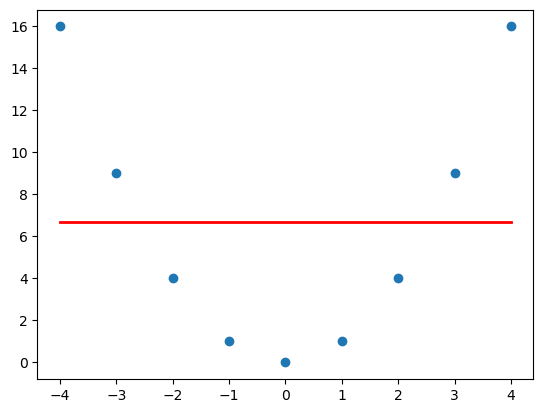

In [11]:
plt.scatter(x, y)
plt.plot(x, y_pred, color='red', linewidth=2);
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Mean Absolute Error:', mean_absolute_error(y, y_pred))
print('Mean Squared Error:', mean_squared_error(y, y_pred))
print('R2 score:', r2_score(y, y_pred))

Mean Absolute Error: 5.185185185185186
Mean Squared Error: 34.22222222222222
R2 score: 0.0


## 7/11   Подготовка данных для обучения. Работа с пропусками в данных

In [1]:
import opendatasets as od
import pandas as pd
import numpy as np
import sys
import os
import kagglehub



In [2]:
# Пробуем скачать через официальную библиотеку
try:
    path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
    print("✅ УСПЕХ! Данные в папке:", path)
except Exception as e:
    print("❌ Ошибка:", e)

❌ Ошибка: Kaggle credentials file at /home/itj/.kaggle/kaggle.json is missing 'key' key


In [2]:
sys.version

'3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:16:10) [GCC 11.2.0]'

In [5]:
kagglehub.env

<module 'kagglehub.env' from '/home/itj/anaconda3/lib/python3.13/site-packages/kagglehub/env.py'>

In [3]:
help(kagglehub)

Help on package kagglehub:

NAME
    kagglehub

PACKAGE CONTENTS
    auth
    cache
    clients
    colab_cache_resolver
    competition
    config
    datasets
    datasets_enums
    datasets_helpers
    enum
    env
    exceptions
    gcs_upload
    handle
    hf_datasets
    http_resolver
    integrity
    kaggle_cache_resolver
    logger
    models
    models_helpers
    notebooks
    packages
    pandas_datasets
    polars_datasets
    registry
    resolver
    signing
    tracker
    utility_scripts

VERSION
    1.0.0

FILE
    /home/itj/anaconda3/lib/python3.13/site-packages/kagglehub/__init__.py




In [4]:
# Список файлов в папке
print(os.listdir(path))

['train.csv', 'test.csv', 'data_description.txt', 'sample_submission.csv']


In [ ]:
# Загрузка данных в DataFrame
train_df = pd.read_csv(f"{path}/train.csv")
test_df = pd.read_csv(f"{path}/test.csv")

In [7]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df = train_df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [9]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
df_nan = df.loc[:, df.isnull().any()]
# посмотрим процент пропущенных значений
df_nan.isnull().sum() / len(df_nan) * 100

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [11]:
df = df.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'], axis = 1)


In [12]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)


In [15]:
df['LotFrontage'].describe()

count    1460.000000
mean       69.863699
std        22.027677
min        21.000000
25%        60.000000
50%        69.000000
75%        79.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [17]:
# using median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [19]:
# using mode
df["GarageFinish"] = df["GarageFinish"].fillna(df["GarageFinish"].mode()[0])


In [23]:
df["GarageType"] = df["GarageType"].ffill()
df["Electrical"] = df["Electrical"].bfill()

In [27]:
df["GarageYrBlt"] = df["GarageYrBlt"].interpolate(method="linear", direction = "forward")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

## 8/11   Подготовка данных для обучения (масштабирование)


Нормализация:

$X_{n o r m}=\frac{X-X_{\min }}{X_{\max }-X_{\min }}$

Стандартизация:

$X_{std} = \frac{X-μ}{σ}$

In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np
import pandas as pd

# вектор признаков
X = np.array([[ 1000., -15.,  2.],
              [ 2500.,  10.,  1.],
              [ 3000.,  13., -1.]])

X = pd.DataFrame(X, columns=['f1','f2','f3'])

In [29]:
X

,f1,f2,f3
0,1000.0,-15.0,2.0
1,2500.0,10.0,1.0
2,3000.0,13.0,-1.0


In [30]:
X.mean(axis='rows')

f1    2166.666667
f2       2.666667
f3       0.666667
dtype: float64

In [31]:
X.describe()

,f1,f2,f3
count,3.000000,3.000000,3.000000
mean,2166.666667,2.666667,0.666667
std,1040.833000,15.373137,1.527525
min,1000.000000,-15.000000,-1.000000
25%,1750.000000,-2.500000,0.000000
50%,2500.000000,10.000000,1.000000
75%,2750.000000,11.500000,1.500000
max,3000.000000,13.000000,2.000000


In [32]:
std = StandardScaler()
std.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [34]:
X_std = std.transform(X)
X_std

array([[-1.37281295, -1.40746549,  1.06904497],
       [ 0.39223227,  0.58423096,  0.26726124],
       [ 0.98058068,  0.82323453, -1.33630621]])

Здесь нужно быть аккуратным, так как большинство алгоритмов библиотеки Scikit-learn, несмотря на, то что могут принимать как DataFrame, так и NumPy массивы, возвращают всегда NumPy массив. Поэтому если вы хотите дальше работать с DataFrame, необходимо явным образом его получить.

In [36]:
X_std = pd.DataFrame(X_std, columns=['f1','f2','f3'])
X_std

,f1,f2,f3
0,-1.372813,-1.407465,1.069045
1,0.392232,0.584231,0.267261
2,0.980581,0.823235,-1.336306


In [39]:
X_std.mean(axis='rows').round(0)

f1    0.0
f2    0.0
f3    0.0
dtype: float64

In [40]:
X_std.describe().round(0)

,f1,f2,f3
count,3.0,3.0,3.0
mean,0.0,0.0,0.0
std,1.0,1.0,1.0
min,-1.0,-1.0,-1.0
25%,-0.0,-0.0,-1.0
50%,0.0,1.0,0.0
75%,1.0,1.0,1.0
max,1.0,1.0,1.0


In [41]:
# среднее отклонение по каждому столбцу
X_std.std(axis=0).round()

f1    1.0
f2    1.0
f3    1.0
dtype: float64

In [42]:
mmsc = MinMaxScaler()
X_norm = mmsc.fit_transform(X) # type - numpy array

X_norm = pd.DataFrame(X_norm, columns=['f1','f2','f3'])

In [45]:
X_norm.describe().round(2)

,f1,f2,f3
count,3.00,3.00,3.00
mean,0.58,0.63,0.56
std,0.52,0.55,0.51
min,0.00,0.00,0.00
25%,0.38,0.45,0.33
50%,0.75,0.89,0.67
75%,0.88,0.95,0.83
max,1.00,1.00,1.00


## 9/11   Подготовка данных для обучения. Создание обучающей и валидационной выборок


Обучающая выборка (Training Set) — используется для настройки модели. На её основе алгоритм находит закономерности и обучает параметры модели.

Валидационная выборка (Validation Set) — используется для проверки производительности модели на данных, которые она не видела. Помогает настроить гиперпараметры и выявить переобучение.

Тестовая выборка (Test Set) — применяется для финальной оценки модели после завершения её обучения и настройки.

Стоит заметить, что разделение на подвыборки необходимо только для процесса наиболее оптимального варианта обработки данных, подбора алгоритма ML и дальнейшего обучения. После выбора оптимальной стратегии алгоритм заново обучают на всем наборе данных и отправляют в продакшн.

Также, следует отметить, что все алгоритмы — будь то алгоритмы ML или алгоритмы предобработки данных — обучаются (fit()) на тренировочной подвыборке. На тестовой подвыборке мы лишь применяем (predict()/transform()) обученные алгоритмы, то есть модели.

**Отложенная выборка**


In [50]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv( "salary_data.csv" )

X = df.iloc[:,:-1].values
y = df.iloc[:,1].values

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (25, 1), (25,)
Test dataset size: (5, 1), (5,)


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics 

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE", metrics.mean_absolute_error(y_test, y_pred))
print("MSE", metrics.mean_squared_error(y_test, y_pred))
print("R2 Score:", model.score(X_test, y_test))

MAE 6980.072585105367
MSE 58984671.99168168
R2 Score: 0.869147229126627


**Кроссвалидация**

Используется для обучения и оценки модели машинного обучения с использованием нескольких частей набора данных. Это означает, что вместо того, чтобы разбивать набор данных только на две части, одну для обучения и другую для тестирования, набор данных делится на большее количество подвыборок.

Существует несколько типов кросс-валидации, среди которых:

* K-блочная кросс-валидация (K-fold cross-validation) — здесь датасет делится на K равных частей (блоков), один из блоков используется для валидации, остальные – для обучения. Процесс повторяется K раз, каждый раз — с новым блоком для валидации.
* Стратифицированная K-блочная кросс-валидация (Stratified K-fold cross-validation) — аналогично K-блочной кросс-валидации, но с учетом пропорции классов в каждом блоке. Используется в случае несбалансированных данных.
* Оставить-P-выборок (Leave-P-Out cross-validation) — здесь на каждой итерации из датасета удаляется P объектов для валидации, остальные используются для обучения. Процесс повторяется для всех возможных комбинаций выборок размера P.

Значение k должно быть тщательно выбрано для выборки данных. Плохо выбранное значение для k может привести к неправильному представлению о качестве модели — например, к оценке с высокой дисперсией (которая может сильно измениться на основе данных, используемых в соответствии с моделью) или к высокой предвзятости (например, переоценка качества модели).

k выбирают обычно 5 или 10, но нет формального правила. По мере того, как k становится больше, разница в размере между тестовой выборкой и подмножествами resampling становится мала. По мере уменьшения этой разницы предвзятость к технике становится меньше.

In [55]:
from sklearn.model_selection import KFold, cross_val_score

# Define the number of folds for cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

In [56]:
lin_reg = LinearRegression()

scores = cross_val_score(lin_reg, X, y, cv=kf, scoring='r2')
print(scores)

[0.90244618 0.96846325 0.91621488 0.98161851 0.84333552]


Как интерпретировать результат:
* Чем более похожи оценки между собой, тем стабильнее и лучше работает модель.
* Если вы видите, что по какому-то из разбиений получилась метрика, сильно отличающаяся от остальных, это говорит о том, что есть некоторые закономерности/особенности в данных, которые модель плохо распознает. В этом случае надо вернуться на несколько шагов назад и попробовать другие способы предобработки данных/параметры алгоритма ML или другой алгоритм в принципе.

In [62]:
scores.mean()

np.float64(0.9224156654035129)

# Модуль 3. Задачи классификации

## 2/10 Теория

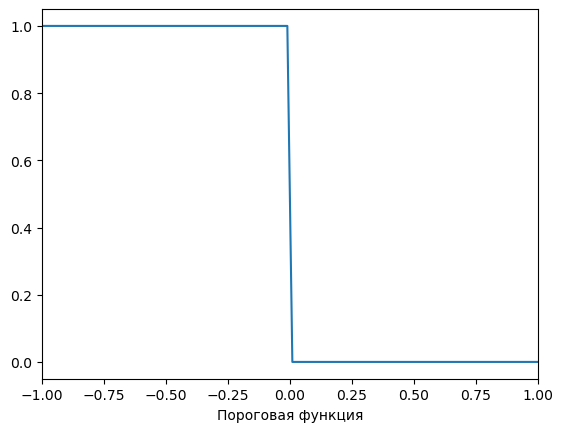

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def loss_function(x):
    return 0 if x > 0 else 1
data = np.linspace(-1, 1, 100)
loss = [loss_function(x) for x in data]

plt.xlabel('Пороговая функция')
plt.xlim(-1, 1)
plt.plot(data, loss)
plt.show()

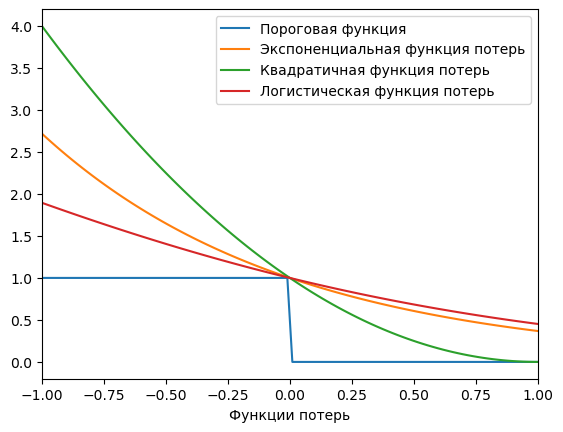

In [7]:
def exp_loss_func(x):
    return np.exp(-x)

def square_loss(x):
    return (1 - x) ** 2

def logistic_loss(x):
    return np.log2(1 + np.exp(-x))

exp_loss = [exp_loss_func(x) for x in data]
logistic_loss = [logistic_loss(x) for x in data]
square_loss = [square_loss(x) for x in data]

plt.xlabel('Функции потерь')
plt.xlim(-1, 1)
plt.plot(data, loss)
plt.plot(data, exp_loss)
plt.plot(data, square_loss)
plt.plot(data, logistic_loss)
plt.legend(['Пороговая функция', 'Экспоненциальная функция потерь', 'Квадратичная функция потерь', 'Логистическая функция потерь'])
plt.show()

## 3/10   Задача классификации (логистическая регрессия)


Логистическая регрессия — это частный случай линейного классификатора. Она обладает одной полезной особенностью — помимо отнесения объекта к определенному классу умеет прогнозировать вероятность $P$ того, что объект относится к этому классу.

Однако логистическая регрессия вовсе не регрессия по своей природе, а классификатор — не перепутайте.

В модели логистической регрессии в качестве такой функции берется сигмоида, которая имеет вид:

$\sigma(z)=\frac{1}{1+\exp (-z)}$

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

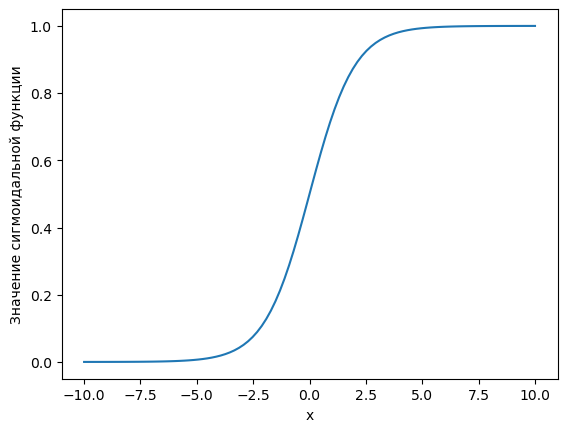

In [9]:
data = np.linspace(-10, 10, 100)
sigmoid_value = list(map(sigmoid, data))

plt.xlabel('x')
plt.ylabel('Значение сигмоидальной функции')
plt.plot(data, sigmoid_value)
plt.show()

$P(y=1 \mid x)$,  для краткости обозначим $p+$, будет равняться

$p_{+}=\frac{1}{1+\exp \left(-\left\langle w, x_{i}\right\rangle\right)}$

Чем больше будет скалярное произведение $\left\langle w, x_{i}\right\rangle$, тем выше окажется предсказанная вероятность.

При этом мы знаем как рассчитать скалярное произведение, но не знаем, как рассчитать вероятность. Выведем необходимые значения:

$\left\langle w, x_{i}\right\rangle=\ln \frac{p_{+}}{1-p_{+}}$

Выражение под логарифмом называется риском (отношение вероятности положительного события к, по сути, вероятности отрицательного события), а вместе с логарифмом это выражение называется логитом. Поэтому метод и называется логистической регрессией: мы приближаем логит линейной комбинацией признаков и весов.

Для обучения этой модели (а точнее, подбора расчетной функции, которую можно использовать для обучения) нам потребуется использовать метод максимального правдоподобия. Он заключается в выборе гипотезы, при которой вероятность получить имеющееся наблюдение максимальна.

С точки зрения реализуемого алгоритма вероятность того, что в выборке встретится объект $x_{i}$ c классом $y_{i}$, равна:

$P\left(y=y_{i} \mid x_{i}\right)=p_{+}^{\left[y_{i}=+1\right]}\left(1-p_{+}\right)^{\left[y_{i}=-1\right]}$


Для всей выборки это значение будет равно произведению ее элементов:

$P(y \mid X)=L(X)=\prod_{i=1}^{l} p_{+}^{\left[y_{i}=+1\right]}\left(1-p_{+}\right)^{\left[y_{i}=-1\right]}$

Проблема произведения в том, что его крайне тяжело оптимизировать. Для решения проблемы произведения рационально использовать логарифмирование:

$-\ln L(X)=-\sum_{i=1}^{l}\left(\left[y_{i}=+1\right] \ln p_{+}+\left[y_{i}=-1\right] \ln \left(1-p_{+}\right)\right)$

Эта функция потерь называется логарифмической функцией потерь (log loss), или кросс-энтропией.

Обратите внимание на знак «-» перед логарифмом. Он необходим для того, чтобы перейти от задачи «максимального» правдоподобия к задаче «минимального».

Когда $y$ принимает значения $0$ и $1$, log loss пишется как:

$\begin{aligned}
& -\ln L(X)=-\sum_{i=1}^{l}\left(y_{i} \ln \frac{1}{1+\exp \left(-\left\langle w, x_{i}\right\rangle\right)}+\left(1-y_{i}\right) \ln \left(1-\frac{1}{1+\exp \left(-\left\langle w, x_{i}\right\rangle\right)}\right)\right) \\
& -\ln L(X)=-\sum_{i=1}^{l}\left(y_{i} \ln (\sigma)+\left(1-y_{i}\right) \ln (1-\sigma)\right)
\end{aligned}$

## 4/10   Логистическая регрессия (self implementation)


### self implementation

In [1]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def log_loss(w, b, X, y):
    z = X @ w + b
    y_pred = sigmoid(z)
    
    # Добавляем epsilon, чтобы избежать Nan при log(0)
    eps = 1e-15
    # Теперь предсказания будут больше ноля и меньше единицы
    y_pred = np.clip(y_pred, eps, 1 - eps)
    
    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    grad_w = (X.T @ (y_pred - y)) / X.shape[0]
    grad_b = np.mean(y_pred - y)

    return loss, grad_w, grad_b

def optimize(w, b, X, y, n_iterations, eta):
    losses = []

    for i in range(n_iterations):
        loss, grad_w, grad_b = log_loss(w, b, X, y)
        w -= eta * grad_w
        b -= eta * grad_b
        losses.append(loss)

    return w, b, losses

def predict(w, b, X, p=0.5):
    # Используем матричное умножение (это быстрее циклов)
    z = X @ w + b
    y_proba = sigmoid(z)
    
    # Превращаем вероятности в 0 или 1 по порогу p
    return (y_proba >= p).astype(int)

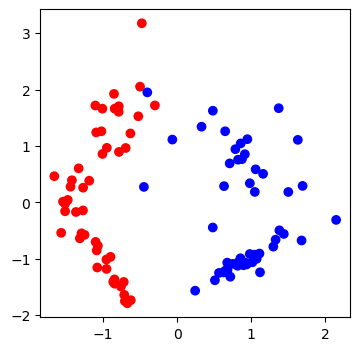

Размер массива признаков обучающей выборки (70, 2)
Размер массива признаков тестовой выборки (30, 2)
Размер массива ответов для обучающей выборки (70,)
Размер массива ответов для тестовой выборки (30,)
Итоговый вектор весов w: [3.76368713 0.22385252]
Точность на обучающей выборке: 98.571
Точность на тестовой выборке: 96.667


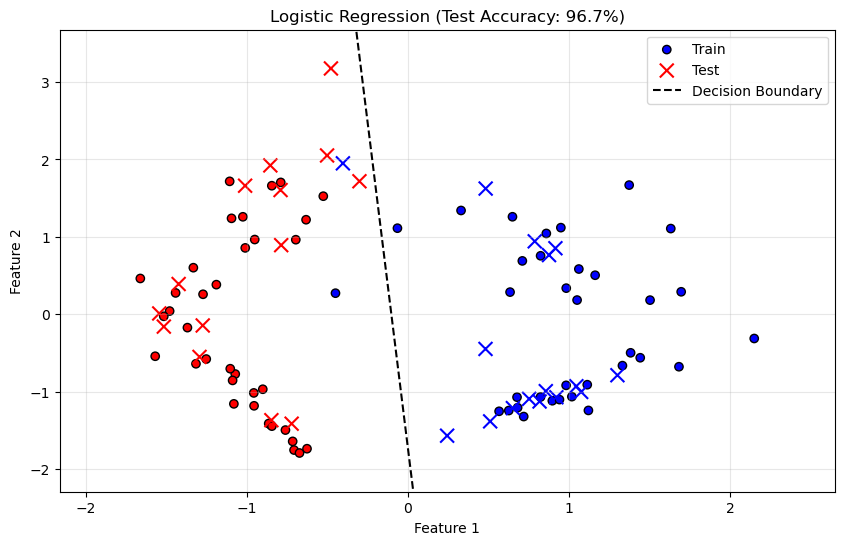

In [2]:
from sklearn import datasets
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# сгеренируем данные
classes = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=1)

# и изобразим их на графике
colors = ListedColormap(['red', 'blue'])

plt.figure(figsize=(4, 4))
plt.scatter([x[0] for x in classes[0]], [x[1] for x in classes[0]], c=classes[1], cmap=colors)
plt.show()

# перемешивание датасета
np.random.seed(12) # это число позволяет постоянно получать одну и ту же "случайность"
shuffle_index = np.random.permutation(classes[0].shape[0])
X_shuffled, y_shuffled = classes[0][shuffle_index], classes[1][shuffle_index]

# разбивка на обучающую и тестовую выборки
train_proportion = 0.7
train_test_cut = int(len(classes[0]) * train_proportion)

X_train, X_test, y_train, y_test = \
    X_shuffled[:train_test_cut], \
    X_shuffled[train_test_cut:], \
    y_shuffled[:train_test_cut], \
    y_shuffled[train_test_cut:]

print("Размер массива признаков обучающей выборки", X_train.shape)
print("Размер массива признаков тестовой выборки", X_test.shape)
print("Размер массива ответов для обучающей выборки", y_train.shape)
print("Размер массива ответов для тестовой выборки", y_test.shape)


# Далее транспонируем матрицы данных, так как нам удобнее работать со строками:

# X_train_tr = X_train.transpose()
# y_train_tr = y_train.reshape(1, y_train.shape[0])
# X_test_tr = X_test.transpose()
# y_test_tr = y_test.reshape(1, y_test.shape[0])


# инициализируем начальные веса
n_features = X_train.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

n_iterations = 1000
eta = 0.05

w, b, losses = optimize(w0, b0, X_train, y_train, n_iterations, eta)

y_predicted_train = predict(w, b, X_train)
y_predicted_test = predict(w, b, X_test)

# В качестве меры точности возьмем долю правильных ответов
train_accuracy = np.mean(y_predicted_train == y_train) * 100
test_accuracy = np.mean(y_predicted_test == y_test) * 100

print(f"Итоговый вектор весов w: {w}")
print(f"Точность на обучающей выборке: {train_accuracy:.3f}")
print(f"Точность на тестовой выборке: {test_accuracy:.3f}")

# Визуализация результата
plt.figure(figsize=(10, 6))

# 1. Рисуем данные
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, label='Train', edgecolors='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colors, marker='x', s=100, label='Test')

# 2. Расчет разделяющей прямой
# Формула: w0*x + w1*y + b = 0  =>  y = -(w0*x + b) / w1
x_min, x_max = X_shuffled[:, 0].min() - 0.5, X_shuffled[:, 0].max() + 0.5
x_values = np.array([x_min, x_max])
y_values = -(w[0] * x_values + b) / w[1]  # Используем индексы [0] и [1]

# 3. Настройка отображения
plt.plot(x_values, y_values, "k--", label="Decision Boundary")

# Ограничиваем оси по реальным границам данных, чтобы график не «сплющивало»
plt.ylim(X_shuffled[:, 1].min() - 0.5, X_shuffled[:, 1].max() + 0.5)
plt.xlim(x_min, x_max)

plt.title(f"Logistic Regression (Test Accuracy: {test_accuracy:.1f}%)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

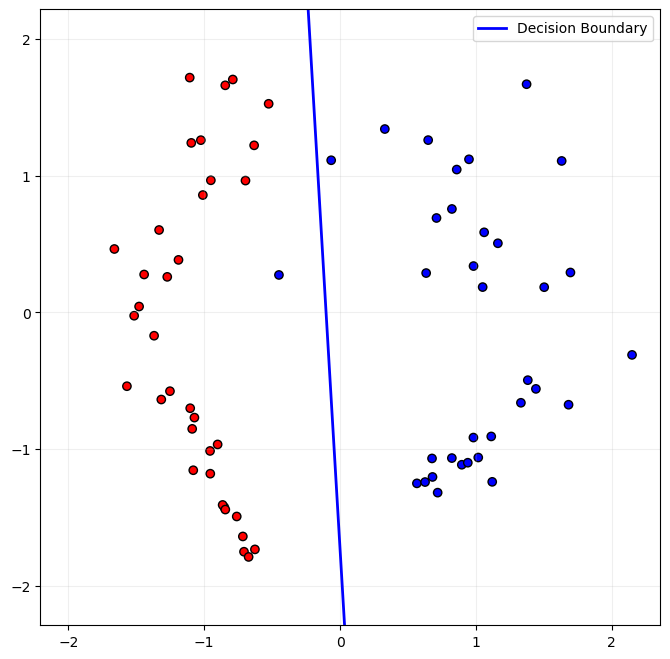

In [4]:
data = np.linspace(-2, 2, 100)

plt.figure(figsize=(8, 8))

# 1. Рисуем точки
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, edgecolors='k')

# 2. СЧИТАЕМ ПРАВИЛЬНУЮ ЛИНИЮ
# Используем формулу: x2 = -(w1*x1 + b) / w2
# w[0] — это w1, w[1] — это w2
line_values = -(w[0] * data + b) / w[1]

# 3. Рисуем линию
plt.plot(data, line_values, label='Decision Boundary', color='blue', linewidth=2)

# Ограничиваем оси, чтобы график был аккуратным
plt.ylim(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5)
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


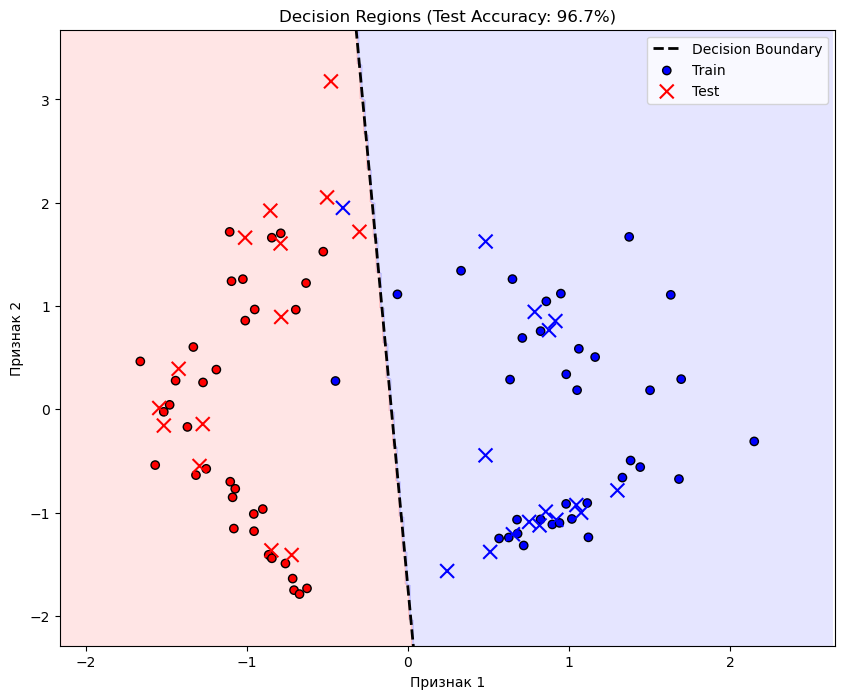

In [5]:
# 1. Создаем сетку (meshgrid) для закрашивания фона
h = .02  # шаг сетки
x_min, x_max = X_shuffled[:, 0].min() - 0.5, X_shuffled[:, 0].max() + 0.5
y_min, y_max = X_shuffled[:, 1].min() - 0.5, X_shuffled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 2. Получаем предсказания для каждой точки сетки
# Раскладываем сетку в один длинный список пар координат и прогоняем через predict
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(w, b, grid_points)
Z = Z.reshape(xx.shape)

# 3. Визуализация
plt.figure(figsize=(10, 8))

# Рисуем области (светлые цвета фона)
from matplotlib.colors import ListedColormap
background_colors = ListedColormap(['#FFAAAA', '#AAAAFF']) # Светло-красный и светло-синий
plt.contourf(xx, yy, Z, cmap=background_colors, alpha=0.3)

# Рисуем разделяющую прямую (черный пунктир)
x_line = np.array([x_min, x_max])
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, "k--", lw=2, label="Decision Boundary")

# Рисуем обучающие (кружки) и тестовые (крестики) данные
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=colors, edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=colors, marker='x', s=100, label='Test')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title(f"Decision Regions (Test Accuracy: {test_accuracy:.1f}%)")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.show()


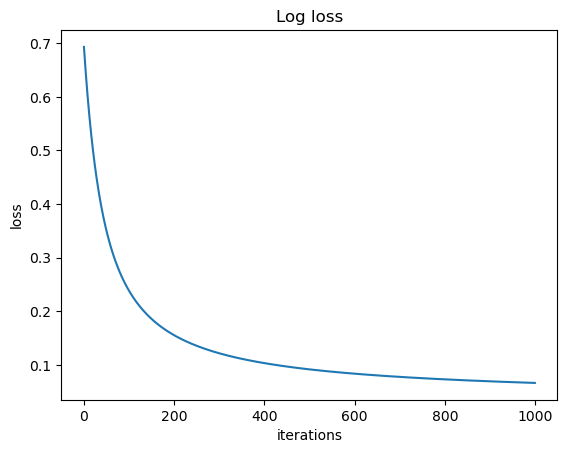

In [15]:
plt.title('Log loss')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.plot(range(len(losses)), losses)

plt.show()

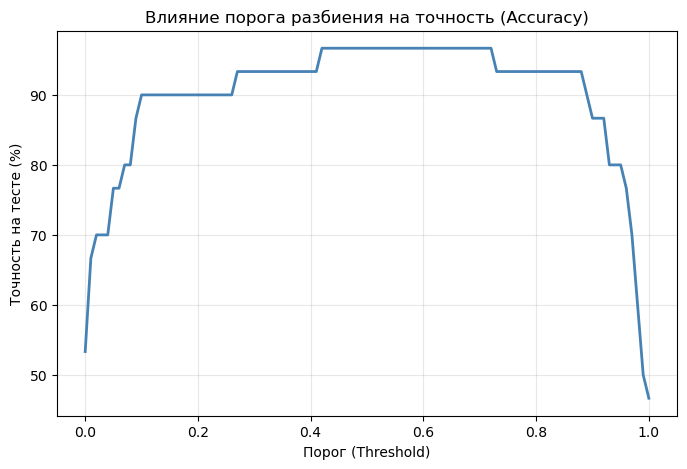

In [17]:
thresholds = []
test_accs = []

# Используем np.linspace для красоты или оставляем range
for p in np.linspace(0, 1, 101):
    # ВАЖНО: передаем w, b (из обучения), X_test и явно указываем p
    y_predicted_test = predict(w, b, X_test, p)
    
    # Считаем точность (простой и понятный способ)
    accuracy = np.mean(y_predicted_test == y_test) * 100
    
    thresholds.append(p)
    test_accs.append(accuracy)

# Отрисовка
plt.figure(figsize=(8, 5))
plt.plot(thresholds, test_accs, color='steelblue', linewidth=2)
plt.title("Влияние порога разбиения на точность (Accuracy)")
plt.xlabel("Порог (Threshold)")
plt.ylabel("Точность на тесте (%)")
plt.grid(True, alpha=0.3)
plt.show()


### тесты с яндекс контест

In [6]:
import numpy as np

X = np.array([[0], [1]])
y = np.array([0, 1])

w = np.zeros(X.shape[1])
b = 0.0

w, b, _ = optimize(w, b, X, y, n_iterations=5000, eta=0.5)
y_pred = predict(w, b, X)

print(*y_pred)

0 1


In [7]:
import numpy as np

X = np.array([[1], [2], [3], [4]])
y = np.array([0, 0, 1, 1])

w = np.zeros(X.shape[1])
b = 0.0

w, b, _ = optimize(w, b, X, y, n_iterations=5000, eta=0.5)
y_pred = predict(w, b, X)

print(*y_pred)

0 0 1 1


In [33]:
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 0, 0, 1])

w = np.zeros(X.shape[1])
b = 0.0

w, b, _ = optimize(w, b, X, y, n_iterations=5000, eta=0.5)
y_pred = predict(w, b, X)

print(*y_pred)

0 0 0 1


In [29]:
y

array([0, 0, 0, 1])

In [30]:
y_pred

array([0, 0, 0, 1])

In [31]:
X

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

### gemini adds

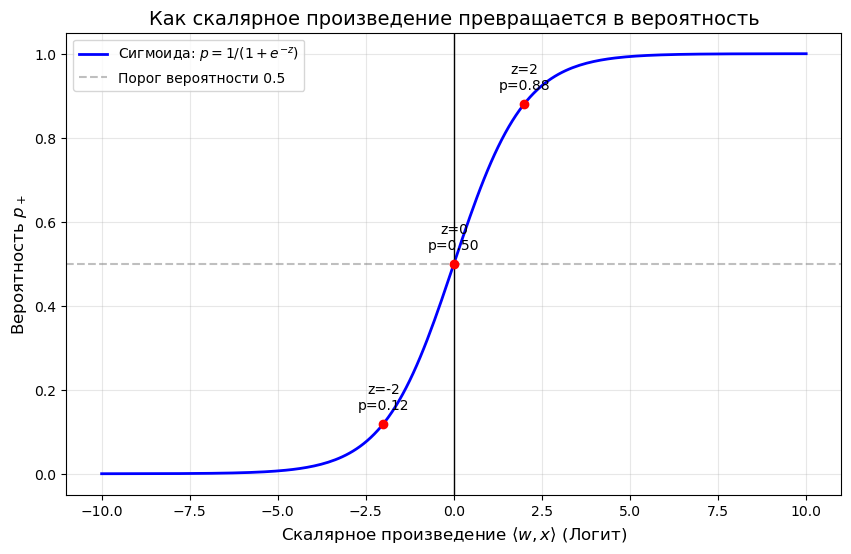

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Определим функцию сигмоиды
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Создадим диапазон значений скалярного произведения (от -10 до 10)
# Это те самые значения <w, x>, которые выдает линейная часть модели
z = np.linspace(-10, 10, 200)
p = sigmoid(z)

# 3. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(z, p, label='Сигмоида: $p = 1 / (1 + e^{-z})$', color='blue', lw=2)

# Добавим важные линии
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Порог вероятности 0.5')
plt.axvline(x=0, color='black', lw=1)

# Подсветим точки для примера
points_to_show = [-2, 0, 2]
for p_z in points_to_show:
    prob = sigmoid(p_z)
    plt.scatter(p_z, prob, color='red', zorder=5)
    plt.annotate(f'z={p_z}\np={prob:.2f}', (p_z, prob), 
                 textcoords="offset points", xytext=(0,10), ha='center')

# Оформление
plt.title('Как скалярное произведение превращается в вероятность', fontsize=14)
plt.xlabel('Скалярное произведение $\langle w, x \\rangle$ (Логит)', fontsize=12)
plt.ylabel('Вероятность $p_+$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


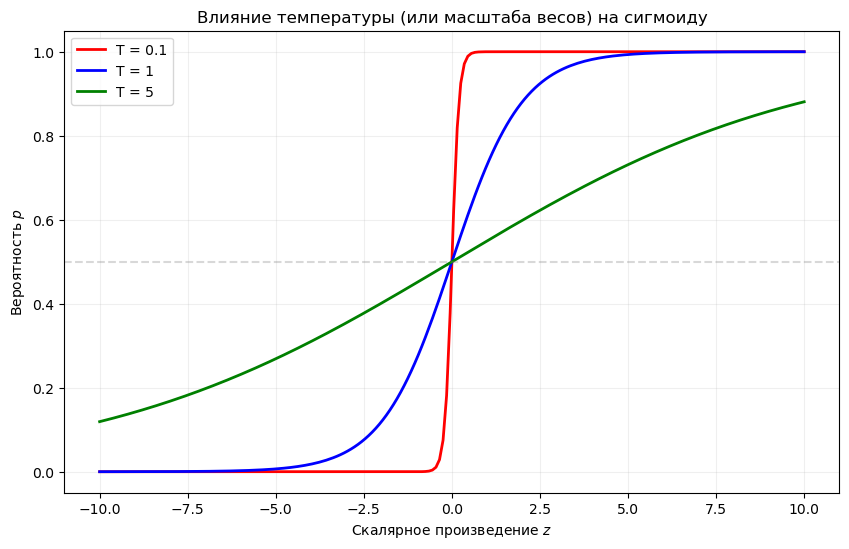

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_temp(z, T):
    return 1 / (1 + np.exp(-z / T))

z = np.linspace(-10, 10, 200)

plt.figure(figsize=(10, 6))

# Разные значения T
# Маленькое T — модель очень резкая (уверенная)
# Большое T — модель очень мягкая (неуверенная)
temperatures = [0.1, 1, 5]
colors = ['red', 'blue', 'green']

for T, color in zip(temperatures, colors):
    p = sigmoid_temp(z, T)
    plt.plot(z, p, label=f'T = {T}', color=color, lw=2)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.title('Влияние температуры (или масштаба весов) на сигмоиду')
plt.xlabel('Скалярное произведение $z$')
plt.ylabel('Вероятность $p$')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


## 5/10   Работа с категориальными переменными


### Dataset Students Performance

Давайте для примера рассмотрим открытый набор данных с платформы Kaggle:

https://www.kaggle.com/datasets/allexanderspb/studentsperformance


In [55]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

df.head(11)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


У нас есть много разных переменных в данных, а именно:

* gender — пол студента;
* race/ethnicity — этническая принадлежность в виде определенной группы;
* parental level of education — уровень образования родителей;
* lunch — обед;
* test preparation course — курс подготовки к тесту;
* math score — оценка по математике;
* reading score — оценка по чтению;
* writing score — оценка за письменную часть.

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [57]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [58]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [59]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

### Ручное кодирование

In [60]:
gender_map = {'female': 0, 
              'male':1,
             }
gender_map

{'female': 0, 'male': 1}

In [61]:
df['gender'] = df['gender'].map(gender_map)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,standard,none,72,72,74
1,0,group C,some college,standard,completed,69,90,88
2,0,group B,master's degree,standard,none,90,95,93
3,1,group A,associate's degree,free/reduced,none,47,57,44
4,1,group C,some college,standard,none,76,78,75


In [62]:
df.describe()

,gender,math score,reading score,writing score
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,0.482000,66.08900,69.169000,68.054000
std,0.499926,15.16308,14.600192,15.195657
min,0.000000,0.00000,17.000000,10.000000
25%,0.000000,57.00000,59.000000,57.750000
50%,0.000000,66.00000,70.000000,69.000000
75%,1.000000,77.00000,79.000000,79.000000
max,1.000000,100.00000,100.000000,100.000000


### Кодирование с помощью готовых методов


#### Label Encoding

Простой и один из самых популярных способов, в котором категориальные данные, представленные в виде меток или строк, преобразуются в числовой формат. В этом методе кодирования каждой уникальной категории назначается уникальное целое число, эффективно преобразуя категориальные данные в числовые значения.

В библиотеке ``sklearn`` в модуле ``preprocessing`` существует готовый алгоритм ``LabelEncoder``, который отвечает за кодирование переменных. Рассмотрим его работу на примере переменной *test preparation course*.

In [63]:
df['test preparation course'].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

Одной из ключевых особенностей библиотеки Scikit-learn является унифицированный подход к реализации алгоритмов. Большинство алгоритмов машинного обучения и методов предобработки данных в этой библиотеке реализованы в виде классов, что делает их использование интуитивно понятным и последовательным:

* Создание объекта класса (то есть инициализация алгоритма).
* Обучение (``fit()``).
* Применение (``predict()`` для алгоритмов ML, ``transform()`` для алгоритмов предобработки данных.

In [64]:
from sklearn import preprocessing

# инициализация алгоритма кодирования
label_encoder = preprocessing.LabelEncoder()

# обучение
label_encoder.fit(df['test preparation course'])

# применем модель
df['test preparation course'] = label_encoder.transform(df['test preparation course'])
df['test preparation course'].value_counts()

test preparation course
1    642
0    358
Name: count, dtype: int64

На этапе обучения данного алгоритма кодирования он сначала ищет все различные категории в переменной (аналогично функции ``unique()``), далее сортирует категории в лексикографическом порядке и после каждой категории назначает число от $0$ до $N-1$, где $N$ — это число различных категорий в переменной.

Так как ``LabelEncoder`` — алгоритм библиотеки sklearn, это по сути умный кодировщик. То есть он сохраняет словарь соответствия категории и числа, а также способен выполнить обратное преобразования из числового представления в начальное.

Недостатки метода:

* LabelEncoder преобразует категории в целые числа (например, "Cat" → 0, "Dog" → 1, "Fish" → 2). В результате алгоритм воспринимает эти числа как упорядоченные значения, что неверно для категорий, у которых нет естественного порядка. То есть некоторые алгоритмы способны воспринимать это как приоритет определенных категорий, и там, где назначенное число выше, может восприниматься как более значимое значение. Это особенно критично для алгоритмов, зависящих от расстояния (например, kNN, линейные модели и SVM).
* Категории ["Red", "Green", "Blue"] преобразуются в [0, 1, 2]. Алгоритм может ошибочно предположить, что "Green" ближе к "Red", чем к "Blue".
* Сложность работы с множественными категориями. Некоторым объектам может быть сопоставлено сразу несколько категорий, например, какой-то игре может соответствовать сразу два жанра. Для этой игры в ячейке будут записаны сразу два значения, разделенные некоторым разделителем: «Экшн/Стратегия».


#### One-hot encoding

Метод принимает категориальную переменную в качестве аргумента. Далее создается новая переменную для каждой категории, так что каждая фиктивная переменная содержит данные $1$ или $0$.

* 1 — указывает на наличие определенной категории.
* 0 — указывает на отсутствие этой категории.

Для реализации данного метода можно воспользоваться двумя алгоритмами:

``get_dummies()`` — встроенный метод библиотеки Pandas. Это простая функция, а не алгоритм кодирования, поэтому он и называется «глупый». Он не запоминает шаги кодирования, словари и не способен сделать обратного преобразования.

Кодировщик ``OneHotEncoder()`` из библиотеки ``sklearn`` из модуля ``preprocessing``. По принципу работы действует точно так же, как ``get_dummies()``. Основное отличие — это умный кодировщик, то есть это некоторая модель, которая обучалась на данных, запомнила словарь и пр. Дальше эти параметры могут применяться к другому набору данных — например, к новым данным. ``get_dummies()`` — это просто метод класса, который по сути вы одноразово используете.

In [65]:
df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [66]:
df = pd.get_dummies(df, columns=['race/ethnicity'], dtype=int)
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,bachelor's degree,standard,1,72,72,74,0,1,0,0,0
1,0,some college,standard,0,69,90,88,0,0,1,0,0
2,0,master's degree,standard,1,90,95,93,0,1,0,0,0
3,1,associate's degree,free/reduced,1,47,57,44,1,0,0,0,0
4,1,some college,standard,1,76,78,75,0,0,1,0,0


Применим метод для другой переменной ‘parental level of education’, но теперь воспользуемся «умным» кодировщиком из библиотеки sklearn:

``OneHotEncoder`` требует, чтобы данные были в формате двумерного массива (2D-array), поэтому сначала преобразуем столбец в двумерный массив, используя ``.values.reshape(-1, 1)``:

In [67]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [68]:
df['parental level of education'].values.reshape(-1, 1)

array([["bachelor's degree"],
       ['some college'],
       ["master's degree"],
       ["associate's degree"],
       ['some college'],
       ["associate's degree"],
       ['some college'],
       ['some college'],
       ['high school'],
       ['high school'],
       ["associate's degree"],
       ["associate's degree"],
       ['high school'],
       ['some college'],
       ["master's degree"],
       ['some high school'],
       ['high school'],
       ['some high school'],
       ["master's degree"],
       ["associate's degree"],
       ['high school'],
       ['some college'],
       ['some college'],
       ['some high school'],
       ["bachelor's degree"],
       ["master's degree"],
       ['some college'],
       ["bachelor's degree"],
       ['high school'],
       ["master's degree"],
       ['some college'],
       ['some college'],
       ["master's degree"],
       ['some college'],
       ['some college'],
       ["associate's degree"],
       ["associate's degr

In [69]:
from sklearn import preprocessing

# 1. Инициализация алгоритма кодировщика
one_hot_encoder = preprocessing.OneHotEncoder()

# 2. Обучение алгоритма кодировщика
one_hot_encoder.fit(df['parental level of education'].values.reshape(-1, 1))

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

In [70]:
# 3. Применение модели кодировщика
x_new = one_hot_encoder.transform(df['parental level of education'].values.reshape(-1, 1)).toarray()
x_new

array([[0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]], shape=(1000, 6))

``OneHotEncoder``, в отличие от других кодировщиков, возвращает новый объект данных, который самостоятельно необходимо добавить после в исходный датасет:

In [72]:
# Получение названий новых столбцов
encoded_columns = one_hot_encoder.get_feature_names_out(['parental level of education'])
encoded_columns

array(["parental level of education_associate's degree",
       "parental level of education_bachelor's degree",
       'parental level of education_high school',
       "parental level of education_master's degree",
       'parental level of education_some college',
       'parental level of education_some high school'], dtype=object)

In [73]:
# Преобразование в DataFrame для удобства
encoded_df = pd.DataFrame(x_new, columns=encoded_columns)
encoded_df.head()

,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0


In [74]:
# Объединение с исходным DataFrame
df = pd.concat([df, encoded_df], axis='columns')

# Удаление оригинального столбца (опционально)
df = df.drop(columns=['parental level of education'])
df.head()

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,standard,1,72,72,74,0,1,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,0,standard,0,69,90,88,0,0,1,0,0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,standard,1,90,95,93,0,1,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
3,1,free/reduced,1,47,57,44,1,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,standard,1,76,78,75,0,0,1,0,0,0.0,0.0,0.0,0.0,1.0,0.0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   gender                                          1000 non-null   int64  
 1   lunch                                           1000 non-null   object 
 2   test preparation course                         1000 non-null   int64  
 3   math score                                      1000 non-null   int64  
 4   reading score                                   1000 non-null   int64  
 5   writing score                                   1000 non-null   int64  
 6   race/ethnicity_group A                          1000 non-null   int64  
 7   race/ethnicity_group B                          1000 non-null   int64  
 8   race/ethnicity_group C                          1000 non-null   int64  
 9   race/ethnicity_group D                    

In [79]:
# Находим все колонки с типом float
float_cols = df.select_dtypes(include=['float64']).columns

# Перезаписываем их в исходном DataFrame
df[float_cols] = df[float_cols].astype(int)

In [80]:
df.head()

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,standard,1,72,72,74,0,1,0,0,0,0,1,0,0,0,0
1,0,standard,0,69,90,88,0,0,1,0,0,0,0,0,0,1,0
2,0,standard,1,90,95,93,0,1,0,0,0,0,0,0,1,0,0
3,1,free/reduced,1,47,57,44,1,0,0,0,0,1,0,0,0,0,0
4,1,standard,1,76,78,75,0,0,1,0,0,0,0,0,0,1,0


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                                          Non-Null Count  Dtype 
---  ------                                          --------------  ----- 
 0   gender                                          1000 non-null   int64 
 1   lunch                                           1000 non-null   object
 2   test preparation course                         1000 non-null   int64 
 3   math score                                      1000 non-null   int64 
 4   reading score                                   1000 non-null   int64 
 5   writing score                                   1000 non-null   int64 
 6   race/ethnicity_group A                          1000 non-null   int64 
 7   race/ethnicity_group B                          1000 non-null   int64 
 8   race/ethnicity_group C                          1000 non-null   int64 
 9   race/ethnicity_group D                          1000 

В чем преимущества использования «умных» кодировщиков из-под капота библиотеки sklearn:

* Они сохраняют информацию о категориях во время вызова ``fit()`` и применяет ту же логику кодирования при вызове ``transform()``. Это гарантирует, что новые данные обрабатываются точно так же, как и обучающие. В отличие от ``pd.get_dummies``, который работает только один раз на предоставленных данных и не сохраняет никаких параметров. Кодировка новых данных требует повторения всех шагов вручную.
* Они способны обрабатывать неизвестные категории через параметр ``handle_unknown``. Это бывает нужно, когда в новом наборе данных присутствует новая категория, не виданная ранее.

    Например:
    * ``handle_unknown='ignore'``: игнорирует неизвестные категории.
    * ``handle_unknown='infrequent_if_exist'``: объединяет редкие категории в одну группу.
  <br>

* ``OneHotEncoder``: по умолчанию возвращает разреженные матрицы (если ``sparse_output=True``). Это экономит память и ускоряет вычисления при большом числе категорий.
* «Умные» кодировщики поддерживают обработку нескольких категориальных столбцов одновременно. Также они позволяют явно задавать категории (categories) и имеют множество полезных методов, таких как ``get_feature_names_out()`` для получения удобных названий столбцов или ``inverse_transform()``, метод обратного преобразования.
* ``pd.get_dummies``: обладает минимальным набором настроек и предназначен для простых задач.

## 6/10   Работа с категориальными переменными (часть 2)


Одна из сложностей при кодировании переменных — это наличие множественных категорий для одного объекта.

In [4]:
import pandas as pd

df= pd.DataFrame({
    'game': [
        'The Witcher 3', 
        'Minecraft', 
        'Overwatch', 
        'Dark Souls', 
        'Fortnite', 
        'Civilization VI', 
        'Stardew Valley', 
        'GTA V', 
        'League of Legends', 
        'Among Us'
    ],
    'genres': [
        'RPG,Action,Adventure',
        'Sandbox,Survival,Creative',
        'Shooter,Multiplayer,Action',
        'RPG,Action,Adventure',
        'Battle Royale,Shooter,Multiplayer',
        'Strategy,Simulation,Turn-Based',
        'Simulation,Farming,Indie',
        'Action,Adventure,Open World',
        'MOBA,Multiplayer,Strategy',
        'Social Deduction,Multiplayer,Indie'
    ]
})

df

,game,genres
0,The Witcher 3,"RPG,Action,Adventure"
1,Minecraft,"Sandbox,Survival,Creative"
2,Overwatch,"Shooter,Multiplayer,Action"
3,Dark Souls,"RPG,Action,Adventure"
4,Fortnite,"Battle Royale,Shooter,Multiplayer"
5,Civilization VI,"Strategy,Simulation,Turn-Based"
6,Stardew Valley,"Simulation,Farming,Indie"
7,GTA V,"Action,Adventure,Open World"
8,League of Legends,"MOBA,Multiplayer,Strategy"
9,Among Us,"Social Deduction,Multiplayer,Indie"


Если мы будем кодировать переменную genres с использованием ``LabelEncoder()``, то увидим, что он не распознает множественные категории. Так что он будет кодировать набор категорий для одного объекта целиком. Это неверно по логике и содержанию, поэтому лучше воспользоваться подходом One Hot Encoding.

Здесь, как и в предыдущем уроке, можно применить как «умный» кодировщик из библиотеки sklearn, так и «глупый», встроенный в библиотеку Pandas:

In [7]:
df_dummies = df['genres'].str.get_dummies(sep=',')
df_dummies.head()

,Action,Adventure,Battle Royale,Creative,Farming,Indie,MOBA,Multiplayer,Open World,RPG,Sandbox,Shooter,Simulation,Social Deduction,Strategy,Survival,Turn-Based
0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
2,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0


Обратите внимание на два нюанса при использовании данного метода:

1. Метод не изменяет исходный датасет.
Этот метод создает новый DataFrame с закодированными переменными. Если вы хотите добавить закодированные столбцы в исходный DataFrame, необходимо явно использовать pd.concat.
2. Названия новых переменных.
Новые столбцы получают названия, соответствующие значениям категорий. Эти названия не содержат префикса исходной колонки. Если у вас есть другая переменная, которую вы планируете закодировать аналогично, и в ней есть категории с такими же названиями, это приведет к созданию нескольких столбцов с одинаковыми именами. И это, в свою очередь, может вызвать ошибки или некорректную обработку данных.

Теперь воспользуемся умным кодировщиком из библиотеки sklearn:


In [9]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

# Преобразование строки с категориями в список (list) из категорий
df['genres_split'] = df['genres'].str.split(',')

# Инициализация MultiLabelBinarizer
mlb = MultiLabelBinarizer()

# Применение MultiLabelBinarizer к колонке 'genres'
genres_encoded = mlb.fit_transform(df['genres_split'])

# Создание нового DataFrame с закодированными жанрами
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

# Соединение с исходным DataFrame
df = pd.concat([df, genres_df], axis=1)
df.head()

,game,genres,genres_split,Action,Adventure,Battle Royale,Creative,Farming,Indie,MOBA,...,Multiplayer,Open World,RPG,Sandbox,Shooter,Simulation,Social Deduction,Strategy,Survival,Turn-Based
0,The Witcher 3,"RPG,Action,Adventure","[RPG, Action, Adventure]",1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,Minecraft,"Sandbox,Survival,Creative","[Sandbox, Survival, Creative]",0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,Overwatch,"Shooter,Multiplayer,Action","[Shooter, Multiplayer, Action]",1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
3,Dark Souls,"RPG,Action,Adventure","[RPG, Action, Adventure]",1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,Fortnite,"Battle Royale,Shooter,Multiplayer","[Battle Royale, Shooter, Multiplayer]",0,0,1,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0


## 7/10   Логистическая регрессия (sklearn)


Scikit-learn (или коротко sklearn) — это одна из самых популярных библиотек для машинного обучения в Python. Она предоставляет простой и удобный интерфейс для реализации, обучения и оценки различных моделей машинного обучения, таких как линейная регрессия, логистическая регрессия, деревья решений, случайные леса, кластеризация и многие другие алгоритмы.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

Рассмотрим датасет из предыдущего урока для примера с платформы Kaggle и предположим, что нам необходимо определить пол студента, то есть реализовать алгоритм бинарной классификации (female и male):

In [62]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

df.head(11)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


Когда вы готовите данные для обучения модели, важно следовать правильному порядку операций, чтобы обеспечить корректность и качество модели. Поэтому мы сначала разделим наш исходный набор данных на тренировочную и тестовую подвыборки, а далее будет делать все преобразования и обучать алгоритм логистической регрессии:

In [63]:
from sklearn.model_selection import train_test_split

# выделяем вектор признаков
X = df.drop(columns='gender')
# выделяем вектор целевой переменной
y = df['gender']

# Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Так как большая часть переменных у нас представлена в виде категорий типа «строка», то сначала закодируем их:



In [64]:
from sklearn.preprocessing import OrdinalEncoder

categorical_features = ['race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for column in categorical_features:
    label_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    
    # Обучаем на тренировочной подвыборке и сразу преобразовываем ее
    X_train[column] = label_encoder.fit_transform(X_train[column].values.reshape(-1, 1))
    
    # Преобразуем тестовую подвыборку с использованием того же обученного кодировщика
    X_test[column] = label_encoder.transform(X_test[column].values.reshape(-1, 1))

X_train

,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
29,3.0,3.0,1.0,1.0,62,70,75
535,2.0,1.0,0.0,0.0,66,83,83
695,3.0,4.0,0.0,1.0,79,89,86
557,2.0,3.0,0.0,1.0,61,67,66
836,4.0,2.0,1.0,1.0,73,64,57
...,...,...,...,...,...,...,...
106,3.0,3.0,1.0,1.0,87,100,100
270,2.0,1.0,1.0,1.0,69,63,61
860,2.0,0.0,1.0,1.0,53,62,53
435,2.0,4.0,0.0,0.0,50,48,53


Важно осознанно подходить к выбору метода кодирования переменных. В данном случае для быстроты и удобства мы используем ``OrdinalEncoder()``. Он работает аналогично ``LabelEncoder()``, но обычно применяется для кодирования признаков, а ``LabelEncoder()`` для кодирования целевой переменной, а также заменяет неизвестные категории на $-1$.

Теперь закодируем целевую переменную:



In [65]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

Теперь создадим модель логистической регрессии и обучим ее на тренировочной подвыборке:

In [66]:
model = LogisticRegression(max_iter=120)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Подскажем ответы для тестовой подвыборки:



In [67]:
y_pred = model.predict(X_test)


Так как логистическая регрессия — это линейная модель, которая строит гиперплоскость, разделяющую наши объекты на классы, мы можем восстановить уравнение разделяющей плоскости:

In [68]:
w0 = model.intercept_
w = model.coef_

В итоге получаем такое уравнение:



In [69]:
# Получаем коэффициенты (для n признаков) и смещение
coefficients = model.coef_[0]  # Коэффициенты для признаков
intercept = model.intercept_[0]  # Смещение

# Записываем уравнение разделяющей гиперплоскости
equation = " + ".join([f"{round(coefficients[i], 4)}*x{i+1}" for i in range(len(coefficients))])
equation = f"({round(intercept, 4)}) + " + equation

print(f"Уравнение разделяющей гиперплоскости: {equation}")

Уравнение разделяющей гиперплоскости: (5.3659) + -0.224*x1 + -0.0329*x2 + -0.7638*x3 + -1.9376*x4 + 0.4126*x5 + -0.0298*x6 + -0.4172*x7


Признаки, у которых веса стремятся к нулю, наименее значимы. Чем больше вес по модулю, тем больше признак вносит вклад в уравнение, а значит, тем более он значим.

**gemini** update with scaler and max_iter=1000

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Лучший вариант: масштабирование + увеличение итераций
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [56]:
y_pred = model.predict(X_test)


Так как логистическая регрессия — это линейная модель, которая строит гиперплоскость, разделяющую наши объекты на классы, мы можем восстановить уравнение разделяющей плоскости:

In [57]:
w0 = model.named_steps['logisticregression'].intercept_
w = model.named_steps['logisticregression'].coef_

In [58]:
# Получаем коэффициенты (для n признаков) и смещение
coefficients = model[1].coef_[0]  # Коэффициенты для признаков
intercept = model[1].intercept_[0]  # Смещение

# Записываем уравнение разделяющей гиперплоскости
equation = " + ".join([f"{round(coefficients[i], 4)}*x{i+1}" for i in range(len(coefficients))])
equation = f"({round(intercept, 4)}) + " + equation

print(f"Уравнение разделяющей гиперплоскости: {equation}")

Уравнение разделяющей гиперплоскости: (-0.1466) + -0.219*x1 + -0.076*x2 + -0.3055*x3 + -0.7476*x4 + 4.8984*x5 + -0.7592*x6 + -4.5864*x7


## 8/10   Метрики классификации



### Матрица ошибок (confusion matrix)


Матрица ошибок (confusion matrix) — это основа для вычисления большинства метрик классификации. Она представляет собой матрицу $K$ на $K$ (где $K$ — количества классов), в которой отображаются все возможные комбинации предсказанных и истинных значений классов.


| Предсказанные \ Истинные | $y = 1$ | $y = 0$ |
| :--- | :---: | :---: |
| **$\hat{y} = 1$** | ✅ True Positive (TP) | ❌ False Positive (FP) |
| **$\hat{y} = 0$** | ❌ False Negative (FN) | ✅ True Negative (TN) |


* TP (True Positive, истино-положительное решение): количество правильно классифицированных положительных примеров.
* TN (True Negative, истино-отрицательное решение): количество правильно классифицированных отрицательных примеров.
* FP (False Positive, ложно-положительное решение): количество ложных срабатываний, когда модель неправильно классифицировала отрицательные примеры как положительные. Это ошибка первого рода, по сути — ложное срабатывание.
* FN (False Negative, ложно-отрицательное решение): количество ложных пропусков, когда модель неправильно классифицировала положительные примеры как отрицательные. Это ошибка второго рода, по сути — ложный пропуск.

Например, есть больница и пациенты. Наш классификатор определяет, больной или нет:

* Если наш классификатор определил, что больной пациент здоровый, — это ложный пропуск.
* Если наш классификатор определил, что здоровой пациент больной, — это ложное срабатывание.

### Метрики


**Accuracy**

Accuracy — это наиболее часто используемая метрика. Она показывает долю правильно классифицированных объектов от общего числа объектов:

$\text { Accuracy }=\frac{T P+T N}{T P+T N+F P+F N}$

Точность полезна, если классы сбалансированы, то есть количество положительных и отрицательных примеров примерно одинаково.

**Полнота (Recall)**

Полнота (или чувствительность) измеряет, насколько хорошо модель находит положительные примеры. Она показывает, какую долю положительных примеров модель правильно классифицировала как положительные:

$\text{Recall} = \frac{TP}{TP + FN}$

Полнота полезна, когда важно минимизировать ложные отрицательные срабатывания — например, в медицине, когда важно выявить все заболевания и лучше лишний раз проверить, чем пропустить.

**Точность (Precision)**

Точность измеряет, насколько точно модель классифицирует положительные примеры. Она показывает, какую долю положительных предсказаний модель сделала правильно:

$\text{Precision} = \frac{TP}{TP + FP}$

Точность важна, когда критично минимизировать ложные положительные срабатывания. Например, в задачах спама, где важно, чтобы классификация «спам» была максимально точной.

**F-мера (F1-score)**

F-мера является гармоническим средним между точностью и полнотой. F1-меру используют, когда важно учитывать как ложные положительные, так и ложные отрицательные срабатывания.

Она полезна, когда необходимо сбалансировать точность и полноту, особенно в случае несбалансированных классов:

$\text{F1-score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

Recall, Precision, F1 способны указать на несбалансированность классов в данных, то есть когда количества объектов в одном классе сильно больше, чем в другом. Поэтому, как правило, при построении алгоритма ее оценивают с помощью нескольких метрик, чтобы с разных сторон понять работу модели.

Существует множество и других метрик, но мы в рамках курса остановимся на этих четырех. Оценить вашу модель классификации с помощью данных метрик можно, воспользовавшись все той же библиотекой ``sklearn``, но уже подмодулем ``metrics``:

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')

Accuracy: 0.915
Precision: 0.9215686274509803
Recall: 0.912621359223301
F1-score: 0.9170731707317074


При необходимости мы можем посмотреть также полную матрицу ошибок, чтобы посмотреть распределение ответов модели:

In [71]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 89
FP: 8
FN: 9
TP: 94


# Модуль 4. Задачи классификации (многоклассовая классификация, ансамблевые модели)


## 2/12   Теоретические основы многоклассовой классификации


**Классификация** — это задача машинного обучения с учителем, в которой модель предсказывает категорию (класс) для каждого объекта.

В бинарной классификации всего два класса (например, «спам» или «не спам»).

В многоклассовой классификации три и более классов (например, определение породы кошки: «Британская», «Сиамская», «Мейн-кун»).

Примеры многоклассовой классификации:
* Распознавание рукописных цифр (0-9).
* Классификация животных по фото.
* Определение эмоций по тексту (позитив, нейтрально, негатив).
* Определение вида животных по их характеристикам.

Не все алгоритмы изначально поддерживают работу с несколькими классами. Например, логистическая регрессия, которую вы изучали ранее, в классическом своем варианте подходит только для бинарной классификации. Кстати, почему?

С геометрической точки зрения логистическая регрессия строит одну прямую, плоскость или гиперплоскость, которой разделяет объекты на классы. А как можно догадаться, одной прямой, плоскостью или гиперплоскостью пространство можно разделить только на две части. Так что логистическая регрессия и решает только задачи бинарной классификации.

Существует несколько стратегий для многоклассовой классиификации, в том числе когда мы можем использовать и бинарные классификаторы.

**One-vs-All** (OvA, One-vs-Rest).

В этом случае мы строим K алгоритмов, которые отделяют один определенный класс от всех остальных. Например, если нарисовать в двумерном признаковом пространстве объекты трех классов (K=3), то каждый алгоритм будет определять свою разделяющую гиперплоскость для выделения одного класса от всех остальных.

Плюсы: у него простая реализация, работает с любым бинарным алгоритмом.

Минусы: нужно обучать несколько моделей, возможны конфликты предсказаний.

**One-vs-One** или all-vs-all (все против всех).

Метод «один-против-одного» (one-vs-one) представляет собой альтернативный метод многоклассовой классификации с помощью набора бинарных классификаторов. Для каждой пары классов создается отдельный классификатор.

Если есть K=3 класса (Кот, Собака, Лошадь), то обучаются модели:

* Кот vs Собака.
* Кот vs Лошадь.
* Собака vs Лошадь.
* 
Итоговое предсказание — класс, победивший в большинстве парных сравнений.

Плюсы: более точный метод, так как каждая модель учится на меньших данных.

Минусы: нужно обучать $\frac{K(K-1)}{2}$ бинарных классификатора.

Но некоторые алгоритмы изначально поддерживают многоклассовую классификацию без дополнительных стратегий:

* K-Nearest Neighbors (KNN) — K-ближайших соседей.
* Random Forest — строит деревья решений для нескольких классов.
* Наивный Байес — хорошо работает с текстовыми данными.
* Градиентный бустинг (XGBoost, LightGBM, CatBoost) — мощные ансамблевые методы.
* Нейронные сети — особенно эффективны на сложных данных (картинки, тексты).

## 3/12   Введение в метод K-ближайших соседей (KNN)


🔍 Краткий алгоритм работы KNN

1. Пусть имеется набор данных, состоящий из $N$ объектов $(X_i, y_i)$. Для каждого из них задан класс $C_i$. $X_i$ — вектор признаков $i$-го объекта, $y_i$ — ответ для $i$-го объекта.
2. Выбираем число $K$ — количество соседей. $K$ — любое целое число.
3. Далее вычисляется расстояние от каждого объекта $X_i$ до каждого из объектов $X$ обучающей выборки. Методы расчета расстояния: 
    * Евклидово;
    * Манхэттенское;
    * Косинусное;
    * Хэмминговское.
4. Выбирается $K$ объектов, расстояние до которых минимально.
5. Далее объект относится к классу, к которому относится большинство из выбранных $K$ ближайших соседей, то есть проводится голосование:

$$a(u) = \operatorname{argmax}_{y} \sum_{i=1}^{k} [y_u^{(i)} = y]$$

Под задачу регрессии метод адаптируется довольно легко: на 5 шаге возвращается не метка, а число — среднее (или медианное) значение целевого признака среди соседей.

Описанный выше тип KNN называется Brute-Force, поскольку в нем используется метод полного перебора для поиска ближайших соседей, что делает его простым в реализации, но слишком медленным при работе с большим объемом данных.


Как выбрать оптимальное число соседей:

Маленькое  (например, 1 или 3):
* Модель очень чувствительна к выбросам.
* Возможна переобучаемость.
Большое  (например, 15 или 20):
* Алгоритм становится более устойчивым.
* Возможна потеря важных деталей (размытие границ классов).

Оптимальный выбор $K$ — это баланс между устойчивостью и точностью. Чаще всего используют $K=\sqrt{N}$, где $N$ — количество объектов в обучающей выборке. Помимо этого, рекомендуется перебрать несколько вариантов $K$ и остановиться на лучшем числе соседей.

**Вычислительная сложность алгоритма**

Чтобы вычислить вычислительную сложность KNN, рассмотрим $d$ — мерное пространство, где $k$ — количество соседей, а $n$ — общее количество точек обучающих данных.

Чтобы понять, как можно рассчитать сложность этого алгоритма, взгляните на формальный псевдокод. Каждое вычисление расстояния требует $O(d)$ времени выполнения, поэтому расчет для одной точки до всех других требует $O(nd)$ работы.

Для каждой итерации на третьем шаге мы выполняем $O(n)$ работы, перебирая наблюдения обучающего набора, поэтому в целом шаг требует $O(nk)$ работы. Первый шаг требует только $O(n)$ работы, поэтому мы получаем время выполнения $O(nd + kn)$.

**Преимущества и недостатки**

Плюсы:
* Простота реализации и интерпретации.
* Хорошие результаты на малых наборах данных.
* Можно использовать как для классификации, так и для регрессии.

Минусы:
* Медленный на больших данных (приходится искать соседей в полном наборе).
* Чувствителен к масштабированию признаков (важно нормализовать данные).
* Плохо работает, если классы сильно пересекаются.

## 4/12   Практическое применение KNN
